# Setup

In [3]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from scipy.interpolate import RectBivariateSpline
from scipy.stats import ks_2samp, anderson_ksamp, norm


def setup_style() -> None:
    """
    Apply a clean, publication-ready matplotlib style.
    Call once at the top of each notebook.

    Design principles:
    - Full framed axes (all 4 spines visible)
    - Inward tick marks on all four sides (canonical astronomy convention)
    - Minor ticks enabled
    - No background grid
    - Serif/STIX maths; constrained_layout by default
    """
    mpl.rcParams.update(
        {
            # Typography
            "font.family": "serif",
            "mathtext.fontset": "stix",
            "font.size": 12,
            "axes.titlesize": 12,
            "axes.labelsize": 11,
            "xtick.labelsize": 9.5,
            "ytick.labelsize": 9.5,
            "legend.fontsize": 9.5,
            "figure.titlesize": 13,
            # Lines & markers
            "lines.linewidth": 1.6,
            "lines.markersize": 4.5,
            # Full box frame — ALL four spines ON
            "axes.linewidth": 0.9,
            "axes.spines.top": True,
            "axes.spines.right": True,
            "axes.grid": False,
            # Inward ticks on all 4 sides (astronomy style)
            "xtick.direction": "in",
            "ytick.direction": "in",
            "xtick.top": True,
            "ytick.right": True,
            "xtick.minor.visible": True,
            "ytick.minor.visible": True,
            "xtick.major.width": 0.9,
            "ytick.major.width": 0.9,
            "xtick.minor.width": 0.55,
            "ytick.minor.width": 0.55,
            "xtick.major.size": 4.5,
            "ytick.major.size": 4.5,
            "xtick.minor.size": 2.5,
            "ytick.minor.size": 2.5,
            # Layout
            "figure.dpi": 150,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "figure.constrained_layout.use": True,
        }
    )

In [4]:
setup_style()

# Loading the data

In [8]:
ALL = pd.read_csv(
    "/home/sarah/Documentos/cavity-like-structure/data/processed/gcs-allstars.csv"
)
F = pd.read_csv(
    "/home/sarah/Documentos/cavity-like-structure/data/processed/gcs-Fstars.csv"
)
G = pd.read_csv(
    "/home/sarah/Documentos/cavity-like-structure/data/processed/gcs-Gstars.csv"
)

In [9]:
ALL.shape, F.shape, G.shape

((3673, 57), (2266, 57), (1407, 57))

# Completeness in apparent magnitude

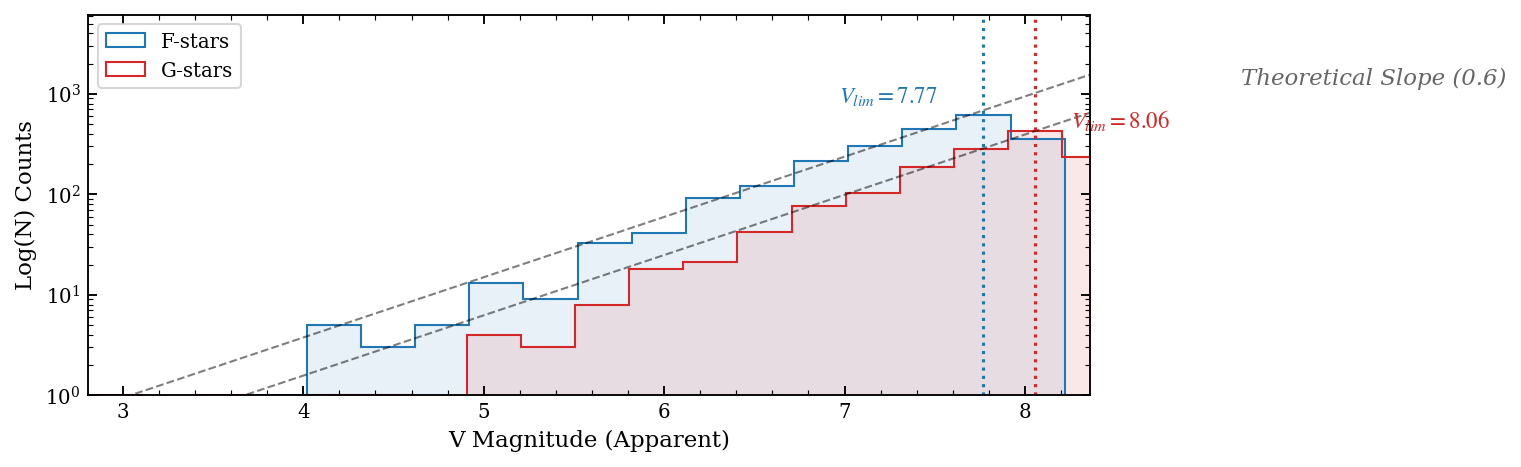

In [10]:
def plot(ax, vmag, label, color):
    """
    Plots the differential magnitude distribution for a stellar population on a given axis,
    overlaying the theoretical Euclidean slope to identify the completeness limit.
    """

    # Bin size setup
    bin_width = 0.3
    bins = np.arange(vmag.min(), vmag.max() + bin_width, bin_width)

    # 1. Main Histogram (Filled + Outline)
    # Transparent fill to add visual volume without obscuring other data
    ax.hist(
        vmag, bins=bins, log=True, color=color, alpha=0.1, histtype="stepfilled", lw=0
    )
    # Strong outline for definition
    counts, edges, _ = ax.hist(
        vmag,
        bins=bins,
        log=True,
        color=color,
        histtype="step",
        lw=1,
        label=f"{label}-stars",
    )

    # Compute bin centers to locate the peak
    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    peak_idx = np.argmax(counts)
    peak_mag = bin_centers[peak_idx]

    # Anchor point for the theoretical line
    # We define the anchor slightly before the peak (safety against index errors)
    anchor_idx = max(0, peak_idx - 2)
    anchor_x = bin_centers[anchor_idx]
    anchor_y = counts[anchor_idx]

    # Theoretical Completeness Relation
    # Assumes uniform spatial density: N(m) propto 10^(0.6 * m)
    x_theory = np.linspace(vmag.min() - 1, vmag.max() + 0.5, 100)
    y_theory = anchor_y * 10 ** (0.6 * (x_theory - anchor_x))

    # Plot the theoretical line (Discrete, dark gray/black to avoid color clashes)
    ax.plot(x_theory, y_theory, color="k", linestyle="--", alpha=0.5, lw=1)

    # 2. Turnover (Vertical Line + Text Annotation)
    # Marks the estimated completeness limit
    ax.axvline(peak_mag, color=color, linestyle=":", lw=1.5)

    # Clean-up trick: Direct annotation on the plot instead of a cluttered legend
    # Adjust text height based on histogram peak
    text_y_pos = counts[peak_idx] * 1.2

    # Specific positioning logic to avoid text overlap between F and G populations
    ax.text(
        peak_mag - 0.8 if label == "F" else peak_mag + 0.2,
        text_y_pos if label == "F" else text_y_pos - 1e2,
        f"$V_{{lim}}={peak_mag:.2f}$",
        color=color,
        fontweight="bold",
        ha="left",
        fontsize=11,
        va="bottom",
    )

    return max(counts)


def plot_completeness_final(df_F, df_G):
    """
    Generates a combined completeness analysis plot for F and G stars.

    It compares the observed magnitude distributions against the expected
    slope of 0.6 to visually demonstrate the completeness limits (turnover points).
    """
    _, ax = plt.subplots(figsize=(10, 3))  # Slightly more compact figure size

    # Plot categories (F in Blue, G in Red)
    max_F = plot(ax, df_F["Vmag"], "F", "tab:blue")
    max_G = plot(ax, df_G["Vmag"], "G", "tab:red")

    # Labels and Titles
    ax.set_xlabel("V Magnitude (Apparent)")
    ax.set_ylabel("Log(N) Counts")

    # Set X-axis limits based on the global range of both samples
    global_min = min(df_F["Vmag"].min(), df_G["Vmag"].min())
    global_max = max(df_F["Vmag"].max(), df_G["Vmag"].max())
    ax.set_xlim(global_min, global_max)

    # Set Y-axis limits:
    # Top is expanded to provide headroom for text labels
    ax.set_ylim(bottom=1, top=max(max_F, max_G) * 10)

    # 3. Annotation of the Theoretical Slope
    # Placed once for the entire plot to avoid redundancy.
    # Coordinates (9.2, max*2) are hardcoded for visual placement.
    ax.text(
        9.2,
        max(max_F, max_G) * 2,
        "Theoretical Slope (0.6)",
        color="k",
        alpha=0.6,
        fontsize=11,
        style="italic",
        ha="left",
    )

    # Clean legend (shows only category names)
    ax.legend(loc="upper left")
    plt.show()


# Execution
plot_completeness_final(F, G)

We address the referee's concern regarding Malmquist bias by defining a volume-complete subsample. To determine the appropriate magnitude cutoff, we analyzed the differential distribution of apparent magnitudes for F and G stars separately. Under a homogeneous stellar spatial distribution, the expected relation is $d\log N/dm = 0.6$. We estimated the completeness limits at the turnover points of each population's count function, finding $V_{\rm lim} = 8.07$ mag for F stars and $V_{\rm lim} = 8.36$ mag for G stars.

In [11]:
F = F[F["Vmag"] <= 8.07]
G = G[G["Vmag"] <= 8.36]

F["SpecType"] = "F"
G["SpecType"] = "G"
ALL = pd.concat([F, G], axis=0, ignore_index=True)

print(f"After magnitude cut:")
print(f"- F-type stars: {len(F)}")
print(f"- G-type stars: {len(G)}")
print(f"- Total: {len(ALL)}")

After magnitude cut:
- F-type stars: 2266
- G-type stars: 1407
- Total: 3673


# 1/Vmax correction for Malmquist bias

To mitigate the selection bias inherent in our magnitude-limited sample (Malmquist Bias), we applied the $1/V_{\max}$ weighting scheme (Schmidt 1968). For each star, we computed the maximum volume $V_{\max}$ within which it could be detected given the survey's apparent magnitude limit. The weight assigned to each star is $w_i = 1/V_{\max}$, which up-weights intrinsically faint (low-luminosity) stars that are only observable within a small volume, while down-weighting intrinsically bright stars that are detectable at large distances.

In [12]:
def Vmax(
    df,
    mag_limit_by_type={"F": 8.07, "G": 8.36},  # Magnitude limits for each spectral type
    type_col="SpecType",
    abs_mag_col="VMAG",  # Absolute magnitude column
    out_col="w_vmax",
):
    # Map the apparent magnitude limit (m_lim) for each spectral type
    mlim = df[type_col].map(mag_limit_by_type).to_numpy()

    # Step 2: Extract the absolute magnitude values (M)
    # The distance modulus uses the absolute magnitude directly
    M_abs = df[abs_mag_col].to_numpy()

    # Step 3: Compute the maximum observable distance r_max
    # Distance modulus: m_lim - M = 5 * log10(r_max) - 5
    # Solving for r_max gives the expression below
    r_max = 10.0 ** ((mlim - M_abs + 5.0) / 5.0)

    # Step 4: Compute the maximum accessible volume for each star
    # The weight is the inverse of this volume
    Vmax = r_max**3
    df[out_col] = 1.0 / Vmax

    return df


# Apply the Vmax weighting
ALL = Vmax(ALL)
F = Vmax(F)
G = Vmax(G)

/tmp/ipykernel_67982/3488544463.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


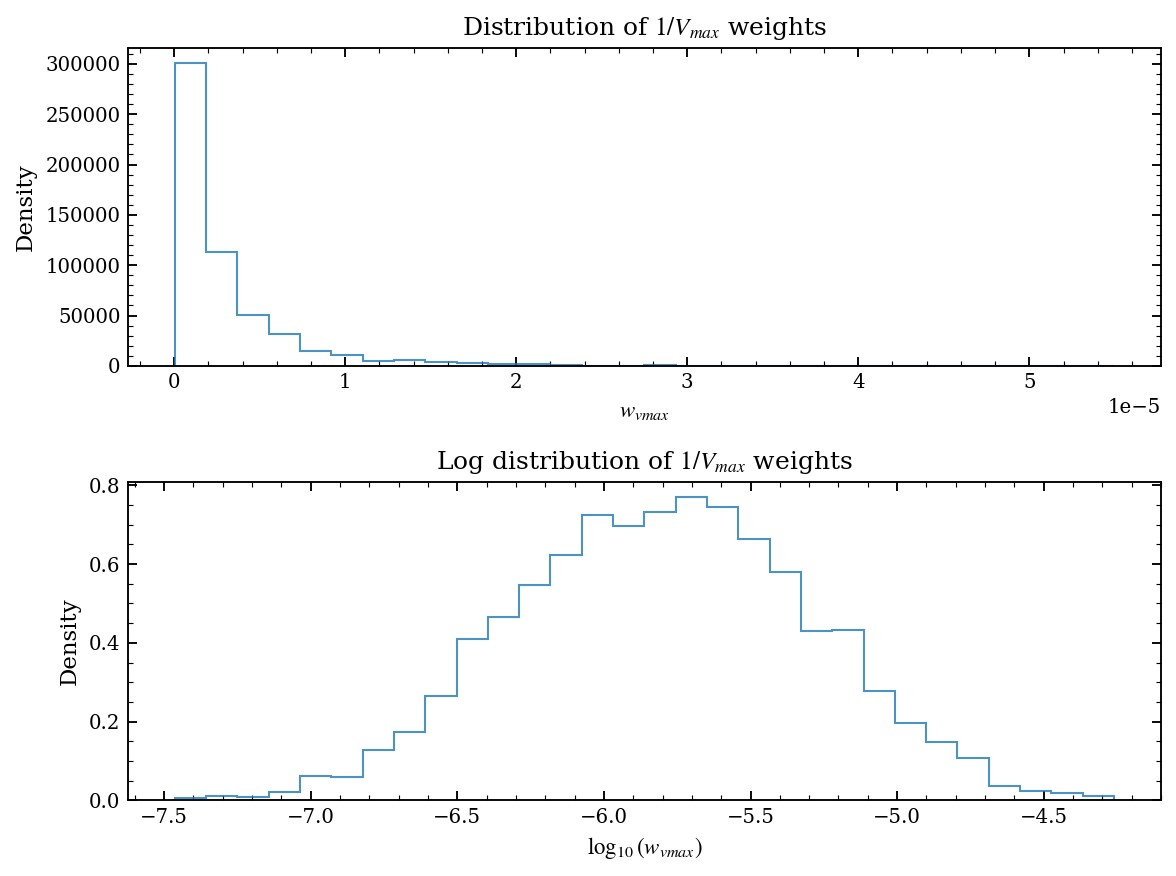

In [13]:
_, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

kwargs = dict(histtype="step", lw=1, density=True, bins=30, alpha=0.8)

ax1.hist(ALL["w_vmax"], **kwargs)
ax1.set_xlabel("$w_{vmax}$")
ax1.set_ylabel("Density")
ax1.set_title("Distribution of $1/V_{max}$ weights")

ax2.hist(np.log10(ALL["w_vmax"]), **kwargs)
ax2.set_xlabel("$\\log_{10}(w_{vmax})$")
ax2.set_ylabel("Density")
ax2.set_title("Log distribution of $1/V_{max}$ weights")

plt.tight_layout()
plt.show()

We verified the distribution of the calculated weights and observed a log-normal (bell-shaped) distribution. This behavior is physically consistent with the luminosity function of main-sequence F and G stars.

In [14]:
def weighted_percentile(values, weights, q):
    # Computes a weighted percentile, with q in the range [0, 100]
    values = np.asarray(values)
    weights = np.asarray(weights)

    # Sort values and reorder weights in the same order
    idx = np.argsort(values)
    v = values[idx]
    w = weights[idx]

    # Compute the cumulative sum of weights
    cw = np.cumsum(w)

    # If total weight is zero or negative, the percentile cannot be computed
    if cw[-1] <= 0:
        return np.nan

    # Target cumulative weight position corresponding to percentile q
    target = q / 100.0 * cw[-1]

    # Linear interpolation between cumulative weight steps
    return np.interp(target, cw, v)

In [15]:
ALL["w_vmax"].min(), ALL["w_vmax"].max()

(np.float64(3.435579478998736e-08), np.float64(5.4954087385762495e-05))

The analysis does not treat all observations equally. Instead of using standard descriptive statistics, each data point is assigned a weight $w_i = 1/V_{\max}^{(i)}$. Stars with small detectable volumes (nearby, faint) receive large weights, while stars with large detectable volumes (bright, distant) receive small weights. This corrects for the fact that nearby faint stars represent a much larger underlying population than the equally rare bright, distant stars captured by the survey.

In [16]:
def plotfig(
    original_dict,
    bootstrap_dict,
    ul,
    plane,
    method="spline36",
    vmin=None,
    vmax=None,
    cmap="Spectral_r",
):
    fig, axs = plt.subplots(2, 4, figsize=(20, 8))

    Ny, Nx = next(iter(original_dict.values())).shape
    x_grid = np.arange(Nx)
    y_grid = np.arange(Ny)

    xnew = np.linspace(0, Nx - 1, Nx)
    ynew = np.linspace(0, Ny - 1, Ny)

    cmap = plt.get_cmap(cmap)
    # cmap.set_bad('black')

    if plane == "XY":
        xlabel = "X [pc]"
        ylabel = "Y [pc]"
    elif plane == "XZ":
        xlabel = "X [pc]"
        ylabel = "Z [pc]"
    elif plane == "ZY":
        xlabel = "Z [pc]"
        ylabel = "Y [pc]"

    all_titles = list(original_dict.keys()) + list(bootstrap_dict.keys())
    all_data = list(original_dict.values()) + list(bootstrap_dict.values())

    if vmin is None:
        vmin = 0

    if vmax is None:
        vmax = np.nanmax([np.nanmax(arr) for arr in all_data])

    for idx, ax in enumerate(axs.flat):
        if idx >= len(all_data):
            fig.delaxes(ax)
            continue

        data_array = all_data[idx]
        spline = RectBivariateSpline(x_grid, y_grid, data_array.T, kx=3, ky=3)
        ima = spline(xnew, ynew)

        cax = ax.imshow(
            ima.T,
            cmap=cmap,
            aspect="auto",
            origin="lower",
            interpolation=method,
            vmin=vmin,
            vmax=vmax,
        )

        cbar = fig.colorbar(cax, ax=ax, pad=0)
        cbar.set_label(all_titles[idx])
        cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        xticklabels = np.arange(-ul, ul + 1, 50)
        xticks = np.linspace(0, ima.shape[1] - 1, len(xticklabels))

        yticklabels = np.arange(-ul, ul + 1, 50)
        yticks = np.linspace(0, ima.shape[0] - 1, len(yticklabels))

        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)

        ax.tick_params(axis="both", which="both", color="white")

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.37, hspace=0.27)

In [17]:
def compute_vsini_bootstrap_maps(
    data,
    PLANE,
    UL,
    INTERVAL,
    TC,
    B,
    ALPHA,
    min_count=20,
    vsini_col="vsini",
    weight_col="w_vmax",
    use_weights=True,
    do_plot=True,
):
    """
    Computes spatially gridded statistics and bootstrap maps for projected rotational velocity (v sin i).
    """

    # 1. Extract coordinates based on the selected projection plane
    if PLANE == "XY":
        x = data["X"]
        y = data["Y"]
    elif PLANE == "XZ":
        x = data["X"]
        y = data["Z"]
    elif PLANE == "ZY":
        x = data["Z"]
        y = data["Y"]
    else:
        raise ValueError("Invalid plane selection. Choose 'XY', 'XZ', or 'ZY'.")

    vsini = data[vsini_col]

    if use_weights:
        raw_weights = data[weight_col].values
        label_mean = r"$\langle v\sin i \rangle$ [km/s] (Weighted)"
    else:
        raw_weights = np.ones(len(vsini))
        label_mean = r"$\langle v\sin i \rangle$ [km/s] (Unweighted)"

    DPtotal = np.std(vsini)

    step = INTERVAL * TC
    ttx = np.arange(-UL, UL + step, step)
    tty = np.arange(-UL, UL + step, step)
    Nx = len(ttx) - 1
    Ny = len(tty) - 1

    meanoriginal = np.zeros((Ny, Nx))
    meanoriginalSD = np.zeros((Ny, Nx))
    percentile25 = np.zeros((Ny, Nx))
    percentile50 = np.zeros((Ny, Nx))
    percentile75 = np.zeros((Ny, Nx))

    meanbootstrap = np.zeros((Ny, Nx))
    meanbootstrapSD = np.zeros((Ny, Nx))
    percentile25boot = np.zeros((Ny, Nx))
    percentile50boot = np.zeros((Ny, Nx))
    percentile75boot = np.zeros((Ny, Nx))

    boot_mean = np.zeros((Ny, Nx))
    boot_se = np.zeros((Ny, Nx))
    ci1 = np.zeros((Ny, Nx))
    ci2 = np.zeros((Ny, Nx))
    shape = np.zeros((Ny, Nx))
    countfXY = np.zeros((Ny, Nx))

    for j in range(Nx):
        for i in range(Ny):
            condition = (
                (ttx[j] <= x) & (x < ttx[j + 1]) & (tty[i] <= y) & (y < tty[i + 1])
            )

            vsini_cond = vsini[condition].values
            w_cond_raw = raw_weights[condition]

            count = len(vsini_cond)
            countfXY[i, j] = count

            if count >= min_count and np.sum(w_cond_raw) > 0:
                w_norm = w_cond_raw / np.sum(w_cond_raw)

                m = np.sum(w_norm * vsini_cond)
                meanoriginal[i, j] = m

                var = np.sum(w_norm * (vsini_cond - m) ** 2)
                meanoriginalSD[i, j] = np.sqrt(var)

                if use_weights:
                    percentile25[i, j] = weighted_percentile(
                        vsini_cond, w_cond_raw, 25.0
                    )
                    percentile50[i, j] = weighted_percentile(
                        vsini_cond, w_cond_raw, 50.0
                    )
                    percentile75[i, j] = weighted_percentile(
                        vsini_cond, w_cond_raw, 75.0
                    )
                else:
                    percentile25[i, j] = np.percentile(vsini_cond, 25.0)
                    percentile50[i, j] = np.percentile(vsini_cond, 50.0)
                    percentile75[i, j] = np.percentile(vsini_cond, 75.0)

                Ncell = count
                bootout = np.empty(B)

                idx_all = np.arange(Ncell)
                for b in range(B):
                    sample_idx = np.random.choice(
                        idx_all,
                        size=Ncell,
                        replace=True,
                        p=w_norm,
                    )
                    sample_vsini = vsini_cond[sample_idx]
                    bootout[b] = np.mean(sample_vsini)

                boot_mean[i, j] = np.mean(bootout)
                boot_se[i, j] = np.std(bootout)
                meanbootstrap[i, j] = boot_mean[i, j]
                meanbootstrapSD[i, j] = boot_se[i, j]

                lower_percentile = (ALPHA / 2) * 100.0
                upper_percentile = (1.0 - ALPHA / 2) * 100.0
                ci1[i, j] = np.percentile(bootout, lower_percentile)
                ci2[i, j] = np.percentile(bootout, upper_percentile)

                percentile25boot[i, j] = np.percentile(bootout, 25.0)
                percentile50boot[i, j] = np.percentile(bootout, 50.0)
                percentile75boot[i, j] = np.percentile(bootout, 75.0)

    length = ci2 - ci1
    shape = (ci2 - boot_mean) / (boot_mean - ci1)
    shape = np.nan_to_num(shape)

    data_dict1 = {
        label_mean: meanoriginal,
        r"$v\sin i$ [km/s] (q = 1/4)": percentile25,
        r"$v\sin i$ [km/s] (q = 1/2)": percentile50,
        r"$v\sin i$ [km/s] (q = 3/4)": percentile75,
    }

    data_dict2 = {
        r"$\langle v\sin i \rangle$ Bootstrap Mean": meanbootstrap,
        r"$\langle v\sin i \rangle$ CI Lower (25%)": percentile25boot,
        r"$\langle v\sin i \rangle$ CI Median (50%)": percentile50boot,
        r"$\langle v\sin i \rangle$ CI Upper (75%)": percentile75boot,
    }

    if do_plot:
        plotfig(
            data_dict1,
            data_dict2,
            UL,
            PLANE,
            method="spline16",
            cmap="jet",
        )

    results = {
        "ttx": ttx,
        "tty": tty,
        "meanoriginal": meanoriginal,
        "meanoriginalSD": meanoriginalSD,
        "percentile25": percentile25,
        "percentile50": percentile50,
        "percentile75": percentile75,
        "meanbootstrap": meanbootstrap,
        "meanbootstrapSD": meanbootstrapSD,
        "ci1": ci1,
        "ci2": ci2,
        "percentile25boot": percentile25boot,
        "percentile50boot": percentile50boot,
        "percentile75boot": percentile75boot,
        "length": length,
        "shape": shape,
        "countfXY": countfXY,
        "DPtotal": DPtotal,
        "data_dict1": data_dict1,
        "data_dict2": data_dict2,
    }

    return results

In [18]:
# User-defined parameters
TC = 20  # Increment value
UL = 150  # Upper limit of parameter interval
DATA_SELECTION = "ALL"  # Options: 'F', 'G', 'ALL'
PLANE = "XY"  # Options: 'XY', 'XZ', 'ZY'
B = 1000  # Number of bootstrap samples
INTERVAL = 1  # Grid interval
CL = 95  # Confidence level
TRIMPCT = 20  # Trim percentage
ALPHA = 0.01  # Alpha for confidence intervals

## All stars (XY plane) - unweighted

/tmp/ipykernel_67982/4242801056.py:133: RuntimeWarning: invalid value encountered in divide
  shape = (ci2 - boot_mean) / (boot_mean - ci1)


RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

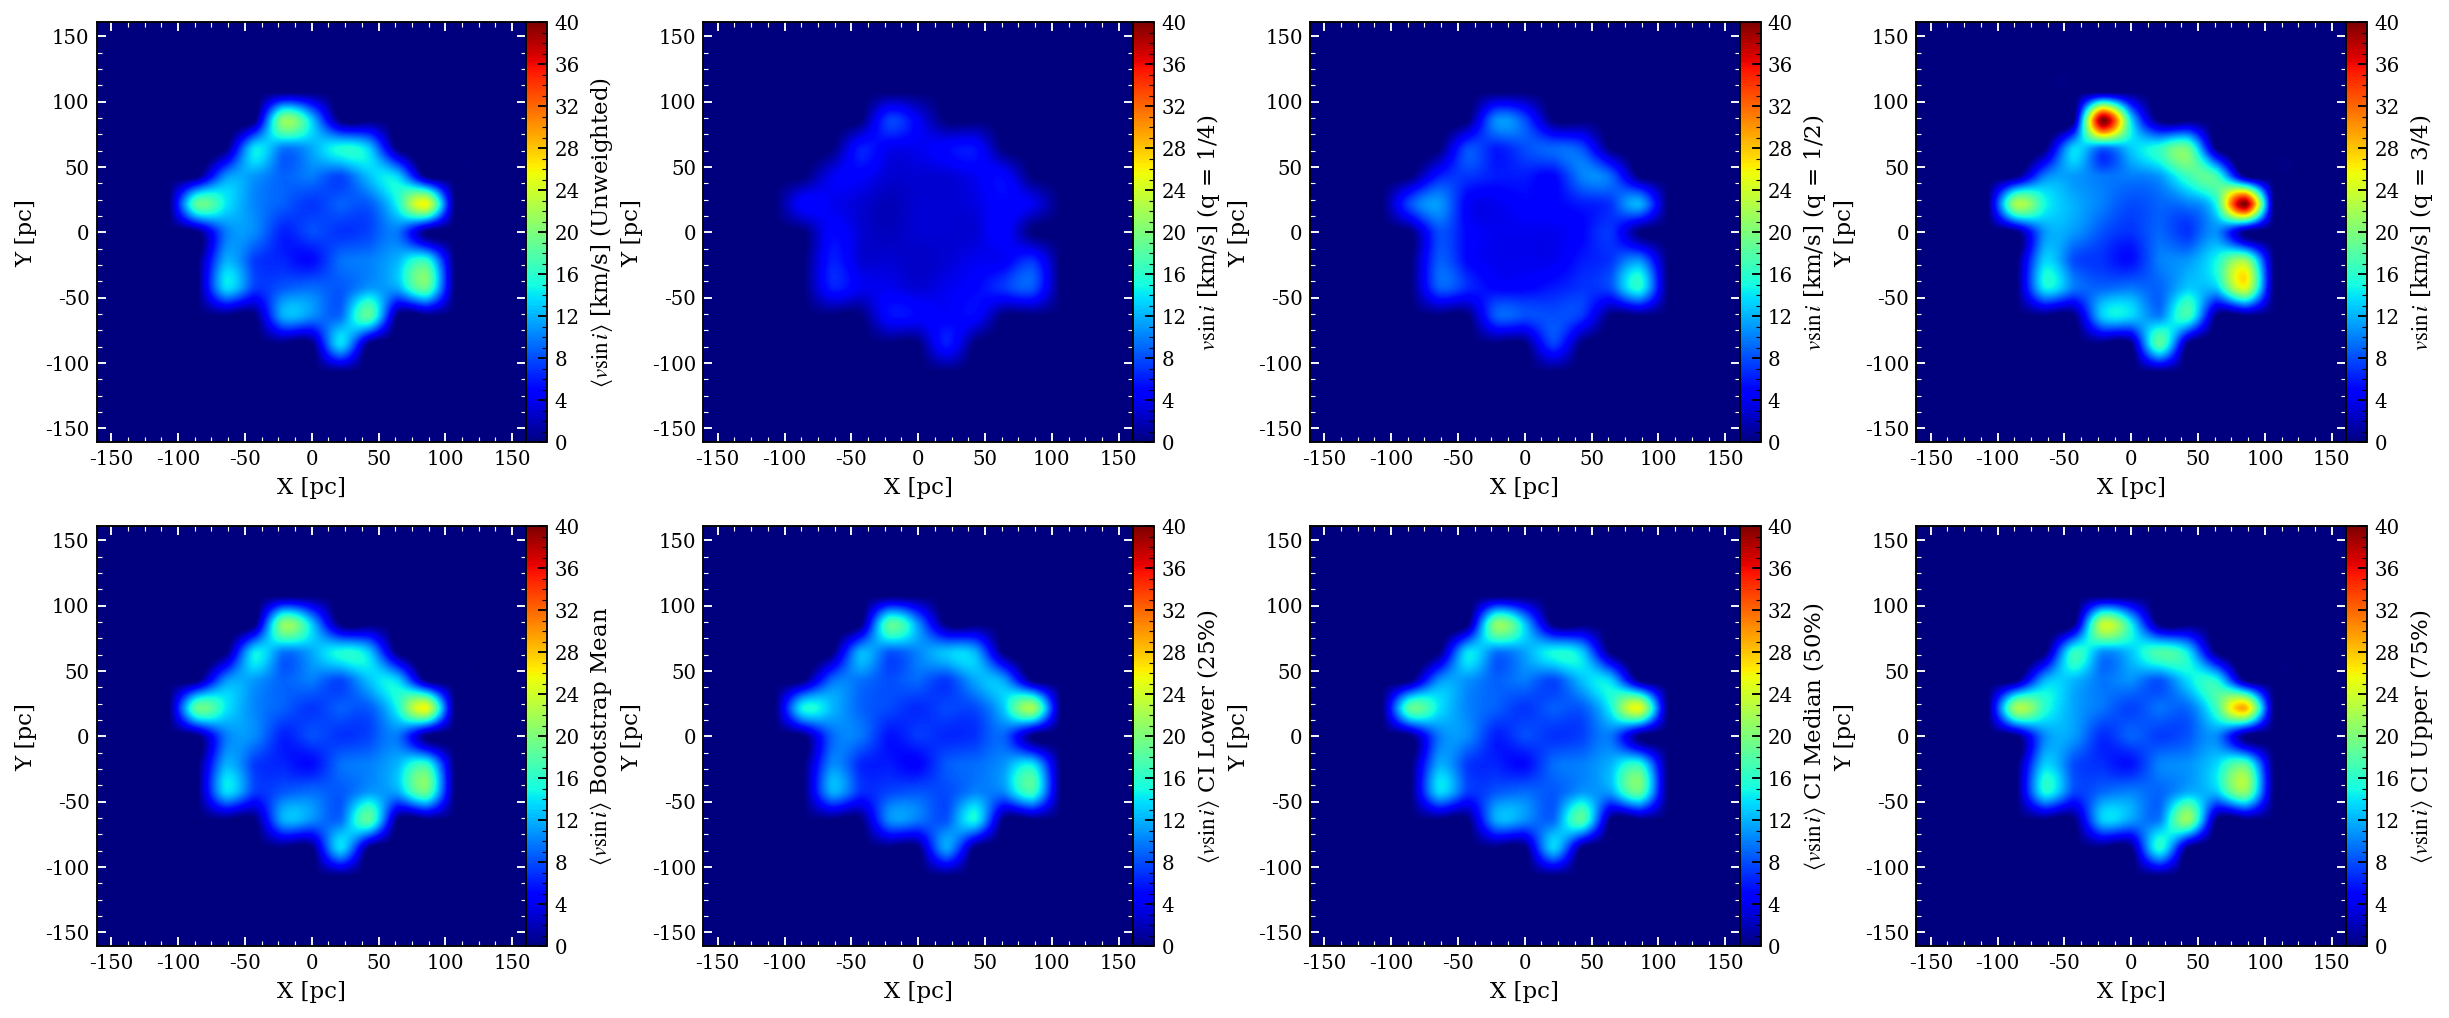

In [19]:
all_xy_unweighted = compute_vsini_bootstrap_maps(
    ALL, "XY", UL=UL, INTERVAL=INTERVAL, B=B, ALPHA=ALPHA, TC=TC, use_weights=False
)

## All stars (XY plane) - weighted

/tmp/ipykernel_67982/4242801056.py:133: RuntimeWarning: invalid value encountered in divide
  shape = (ci2 - boot_mean) / (boot_mean - ci1)


RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

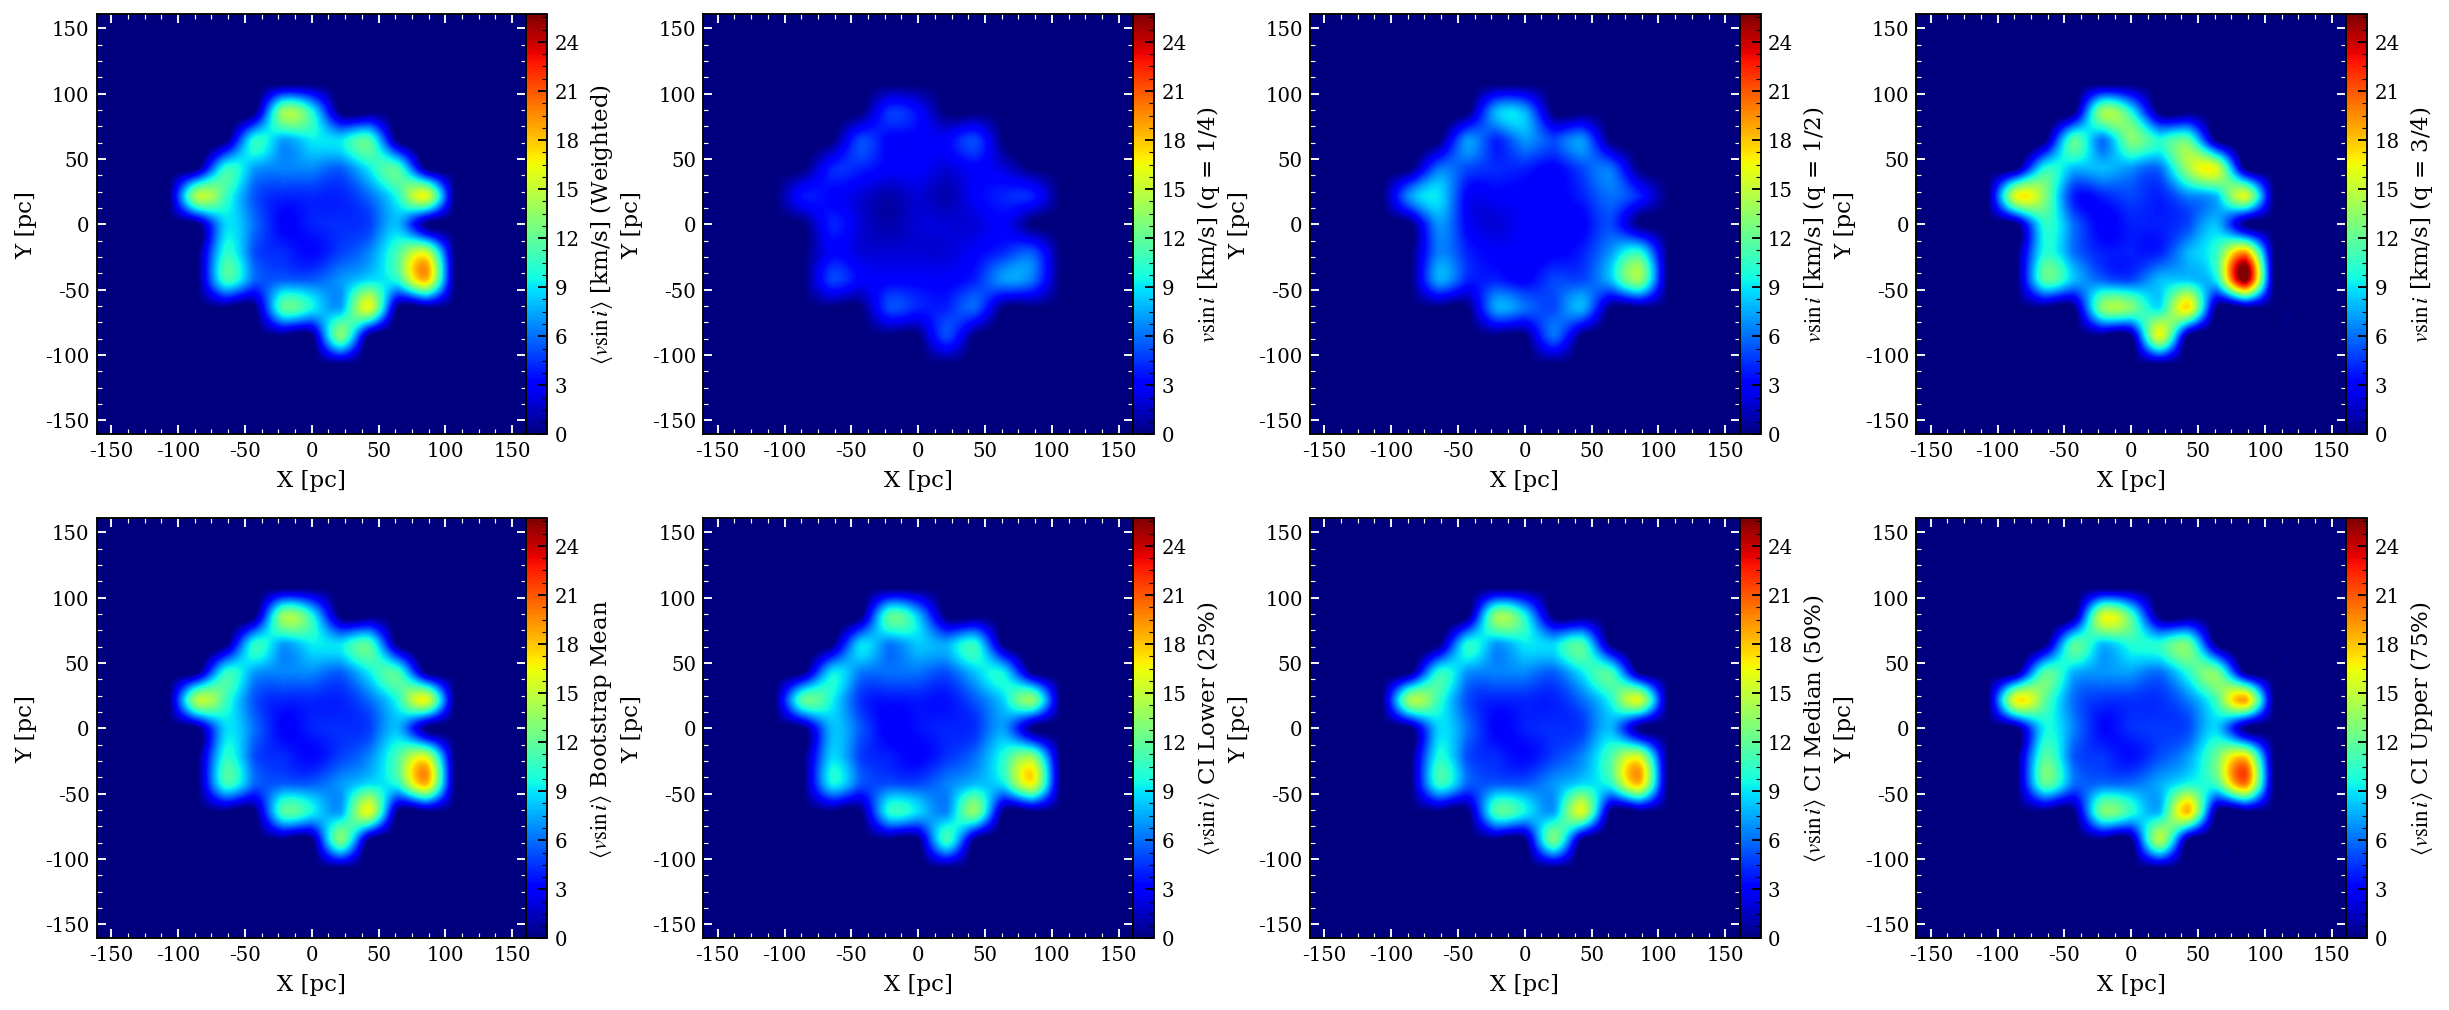

In [20]:
all_xy_weighted = compute_vsini_bootstrap_maps(
    ALL, "XY", UL=UL, INTERVAL=INTERVAL, B=B, ALPHA=ALPHA, TC=TC, use_weights=True
)

## All stars (XZ plane)

/tmp/ipykernel_67982/4242801056.py:133: RuntimeWarning: invalid value encountered in divide
  shape = (ci2 - boot_mean) / (boot_mean - ci1)


RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

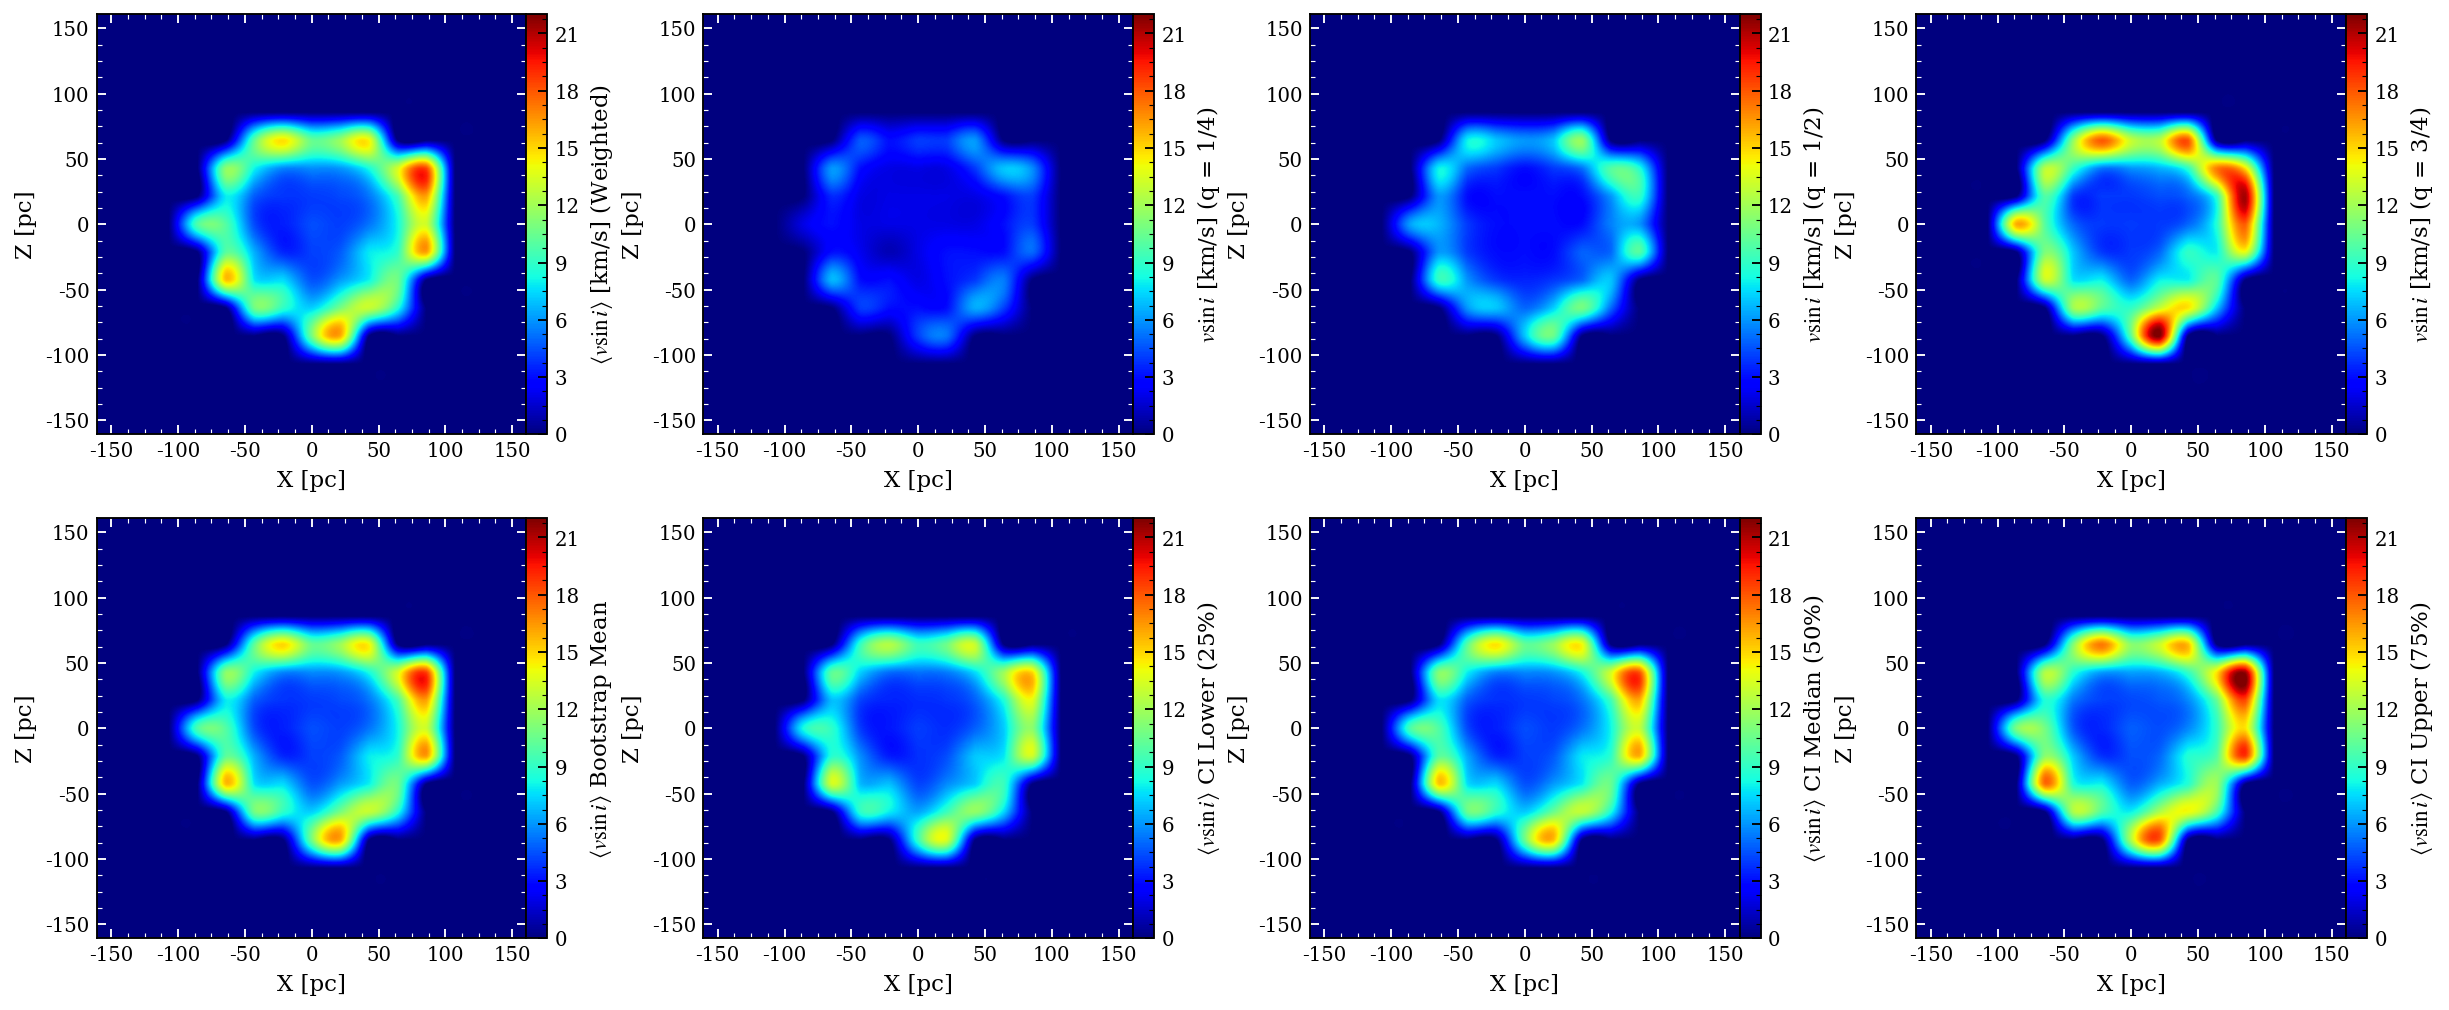

In [21]:
all_xz_weighted = compute_vsini_bootstrap_maps(
    ALL, "XZ", UL=UL, INTERVAL=INTERVAL, B=B, ALPHA=ALPHA, TC=TC, use_weights=True
)

## All stars (ZY plane)

In [ ]:
all_zy_weighted = compute_vsini_bootstrap_maps(
    ALL, "ZY", UL=UL, INTERVAL=INTERVAL, B=B, ALPHA=ALPHA, TC=TC, use_weights=True
)

## F stars (XY plane)

In [ ]:
f_xy_weighted = compute_vsini_bootstrap_maps(
    F, "XY", UL=UL, INTERVAL=INTERVAL, B=B, ALPHA=ALPHA, TC=TC, use_weights=True
)

## F stars (XZ plane)

In [ ]:
f_xz_weighted = compute_vsini_bootstrap_maps(
    F, "XZ", UL=UL, INTERVAL=INTERVAL, B=B, ALPHA=ALPHA, TC=TC, use_weights=True
)

## F stars (ZY plane)

In [ ]:
f_zy_weighted = compute_vsini_bootstrap_maps(
    F, "ZY", UL=UL, INTERVAL=INTERVAL, B=B, ALPHA=ALPHA, TC=TC, use_weights=True
)

## G stars (XY plane)

In [ ]:
g_xy_weighted = compute_vsini_bootstrap_maps(
    G, "XY", UL=UL, INTERVAL=INTERVAL, B=B, ALPHA=ALPHA, TC=TC, use_weights=True
)

## G stars (XZ plane)

In [ ]:
g_XZ_weighted = compute_vsini_bootstrap_maps(
    G, "XZ", UL=UL, INTERVAL=INTERVAL, B=B, ALPHA=ALPHA, TC=TC, use_weights=True
)

## G stars (ZY plane)

In [ ]:
g_zy_weighted = compute_vsini_bootstrap_maps(
    G, "ZY", UL=UL, INTERVAL=INTERVAL, B=B, ALPHA=ALPHA, TC=TC, use_weights=True
)

# Apparent magntiude in XZY maps

RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

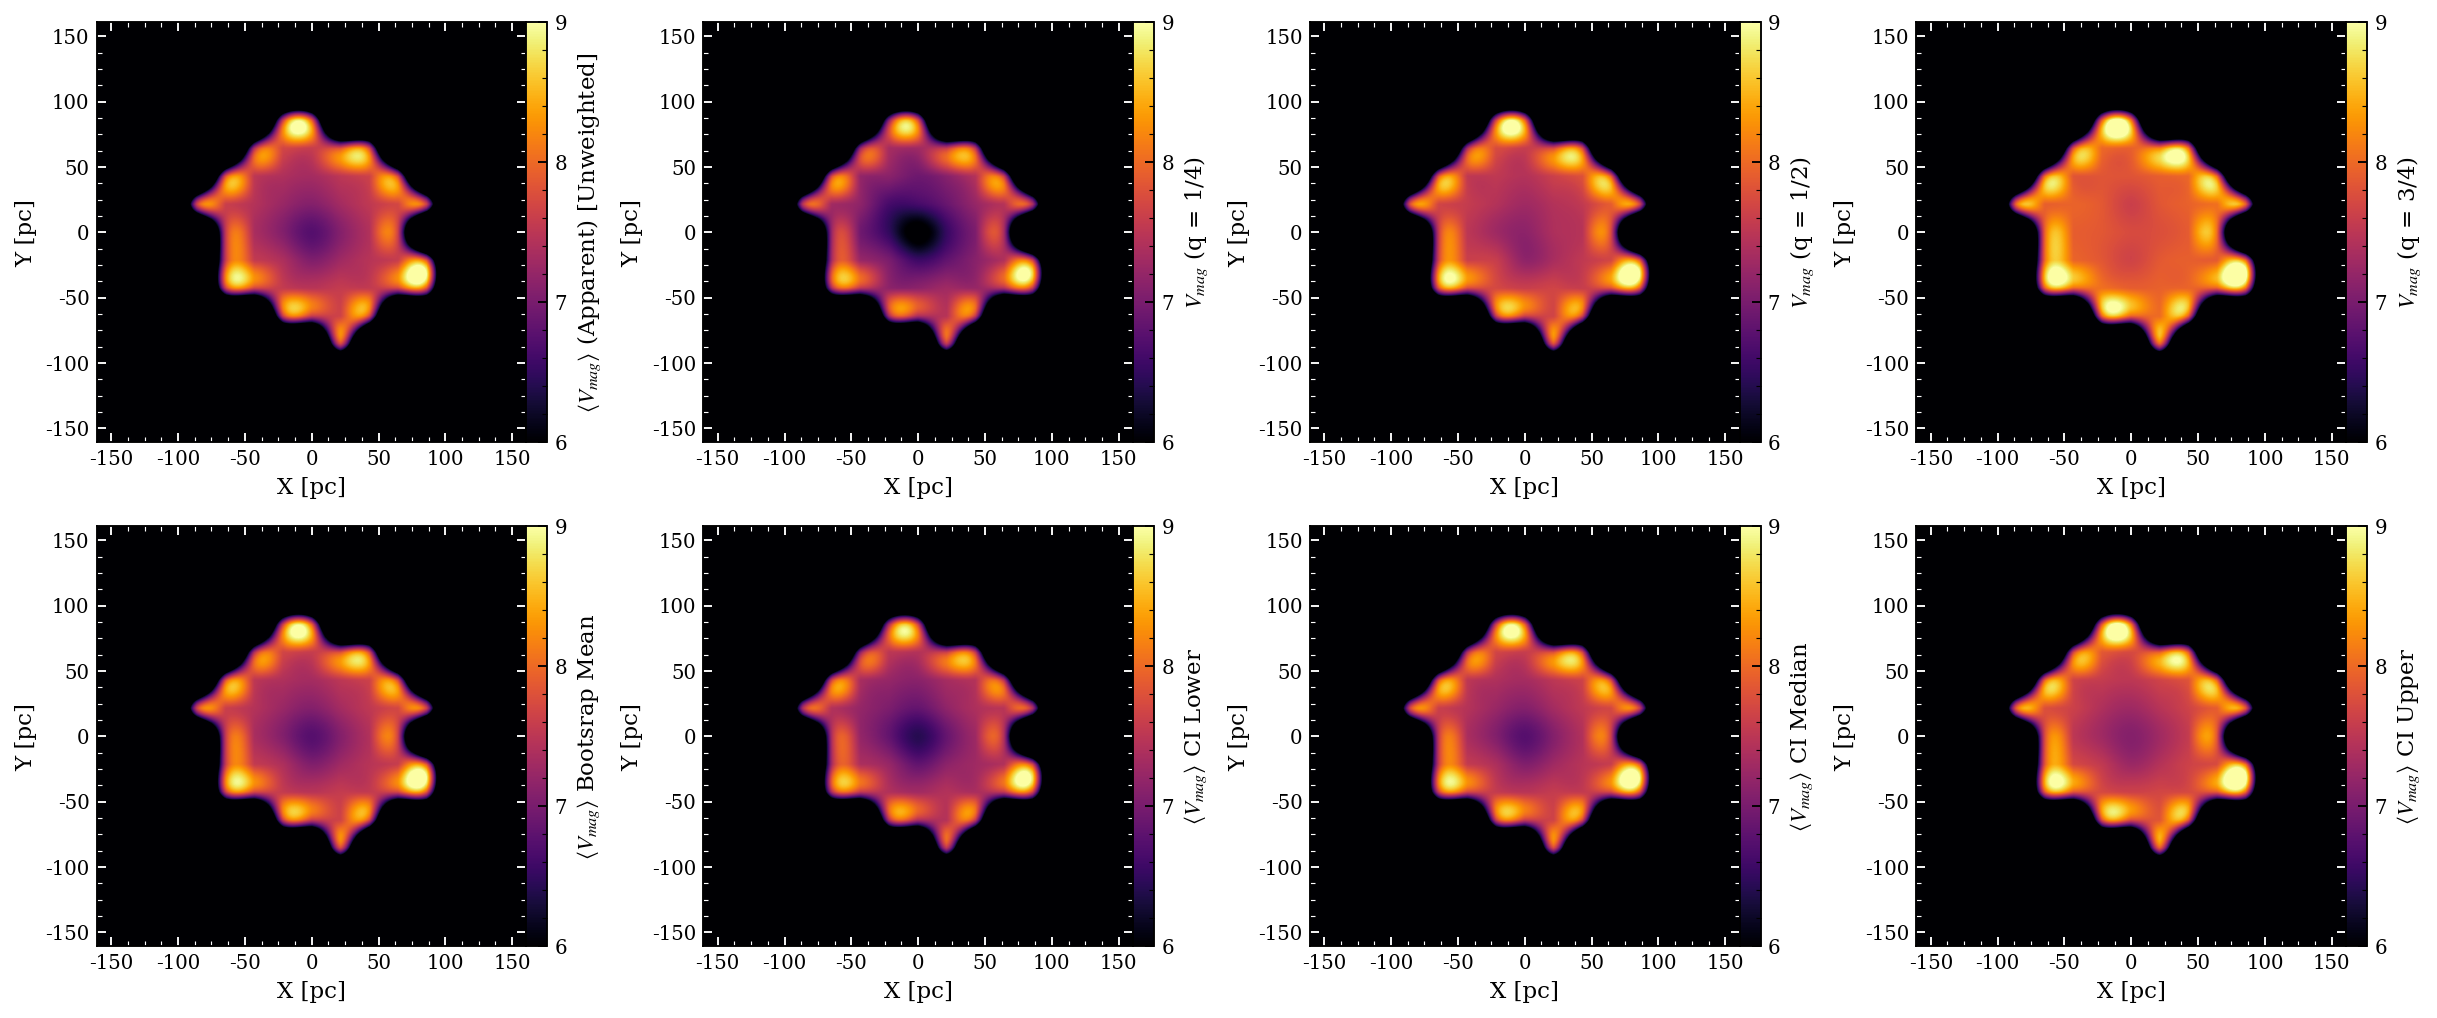

In [22]:
def compute_vmag_unweighted_maps(
    data,
    PLANE,
    UL,
    INTERVAL,
    TC,
    B,
    ALPHA,
    min_count=20,
    vmag_col="Vmag",
    do_plot=True,
):
    if PLANE == "XY":
        x = data["X"]
        y = data["Y"]
    elif PLANE == "XZ":
        x = data["X"]
        y = data["Z"]
    elif PLANE == "ZY":
        x = data["Z"]
        y = data["Y"]
    else:
        raise ValueError("Invalid plane selection.")

    vmag = data[vmag_col]

    step = INTERVAL * TC
    ttx = np.arange(-UL, UL + step, step)
    tty = np.arange(-UL, UL + step, step)
    Nx = len(ttx) - 1
    Ny = len(tty) - 1

    meanoriginal = np.zeros((Ny, Nx))
    percentile25 = np.zeros((Ny, Nx))
    percentile50 = np.zeros((Ny, Nx))
    percentile75 = np.zeros((Ny, Nx))

    meanbootstrap = np.zeros((Ny, Nx))
    percentile25boot = np.zeros((Ny, Nx))
    percentile50boot = np.zeros((Ny, Nx))
    percentile75boot = np.zeros((Ny, Nx))

    for j in range(Nx):
        for i in range(Ny):
            condition = (
                (ttx[j] <= x) & (x < ttx[j + 1]) & (tty[i] <= y) & (y < tty[i + 1])
            )

            vmag_cond = vmag[condition].values
            count = len(vmag_cond)

            if count >= min_count:
                meanoriginal[i, j] = np.mean(vmag_cond)
                percentile25[i, j] = np.percentile(vmag_cond, 25)
                percentile50[i, j] = np.percentile(vmag_cond, 50)
                percentile75[i, j] = np.percentile(vmag_cond, 75)

                bootout = np.empty(B)
                for b in range(B):
                    sample_vmag = np.random.choice(vmag_cond, size=count, replace=True)
                    bootout[b] = np.mean(sample_vmag)

                meanbootstrap[i, j] = np.mean(bootout)

                lower_percentile = (ALPHA / 2) * 100.0
                upper_percentile = (1.0 - ALPHA / 2) * 100.0

                percentile25boot[i, j] = np.percentile(bootout, lower_percentile)
                percentile50boot[i, j] = np.percentile(bootout, 50.0)
                percentile75boot[i, j] = np.percentile(bootout, upper_percentile)

    data_dict1 = {
        r"$\langle V_{mag} \rangle$ (Apparent) [Unweighted]": meanoriginal,
        r"$V_{mag}$ (q = 1/4)": percentile25,
        r"$V_{mag}$ (q = 1/2)": percentile50,
        r"$V_{mag}$ (q = 3/4)": percentile75,
    }

    data_dict2 = {
        r"$\langle V_{mag} \rangle$ Bootsrap Mean": meanbootstrap,
        r"$\langle V_{mag} \rangle$ CI Lower": percentile25boot,
        r"$\langle V_{mag} \rangle$ CI Median": percentile50boot,
        r"$\langle V_{mag} \rangle$ CI Upper": percentile75boot,
    }

    if do_plot:
        plotfig(
            data_dict1,
            data_dict2,
            UL,
            PLANE,
            method="spline16",
            cmap="inferno",
            vmin=6.0,
            vmax=9.0,
        )

    return meanoriginal


vmag_all_xy = compute_vmag_unweighted_maps(
    ALL,
    PLANE="XY",
    UL=150,
    INTERVAL=1,
    TC=20,
    B=1000,
    ALPHA=0.01,
    do_plot=True,
)

To visualize the impact of the magnitude limit on the spatial distribution, we computed the unweighted mean apparent magnitude $\langle V_{\rm mag}\rangle$ in a regular grid across the XY plane. The resulting map confirms the expected radial gradient: stars near the Sun appear brighter on average, while the outer regions approach the survey completeness limit ($V \approx 8-9$ mag). This spatial variation in $\langle V_{\rm mag}\rangle$ directly motivates the $1/V_{\rm max}$ weighting applied throughout the analysis.

# Teff distributions in cavity vs. shell

########## ALL STARS ##########
--- Samples ---
Cavity (R <= 80 pc): 3003 stars
Shell  (R >  80 pc): 670 stars

--- Kolmogorov-Smirnov (KS) Test ---
Statistic: 0.3455
P-value:   1.1219e-58
>> Result: Reject H0 (distributions are DIFFERENT).

--- Anderson-Darling (AD) Test ---
Statistic: 255.0332
P-value:   1.0000e-03
>> Result: Reject H0 (distributions are DIFFERENT).


/tmp/ipykernel_67982/3320480218.py:30: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  ad_stat, ad_crit_vals, ad_p = anderson_ksamp([data_inner, data_outer])
/tmp/ipykernel_67982/3320480218.py:30: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_stat, ad_crit_vals, ad_p = anderson_ksamp([data_inner, data_outer])
/tmp/ipykernel_67982/3320480218.py:95: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


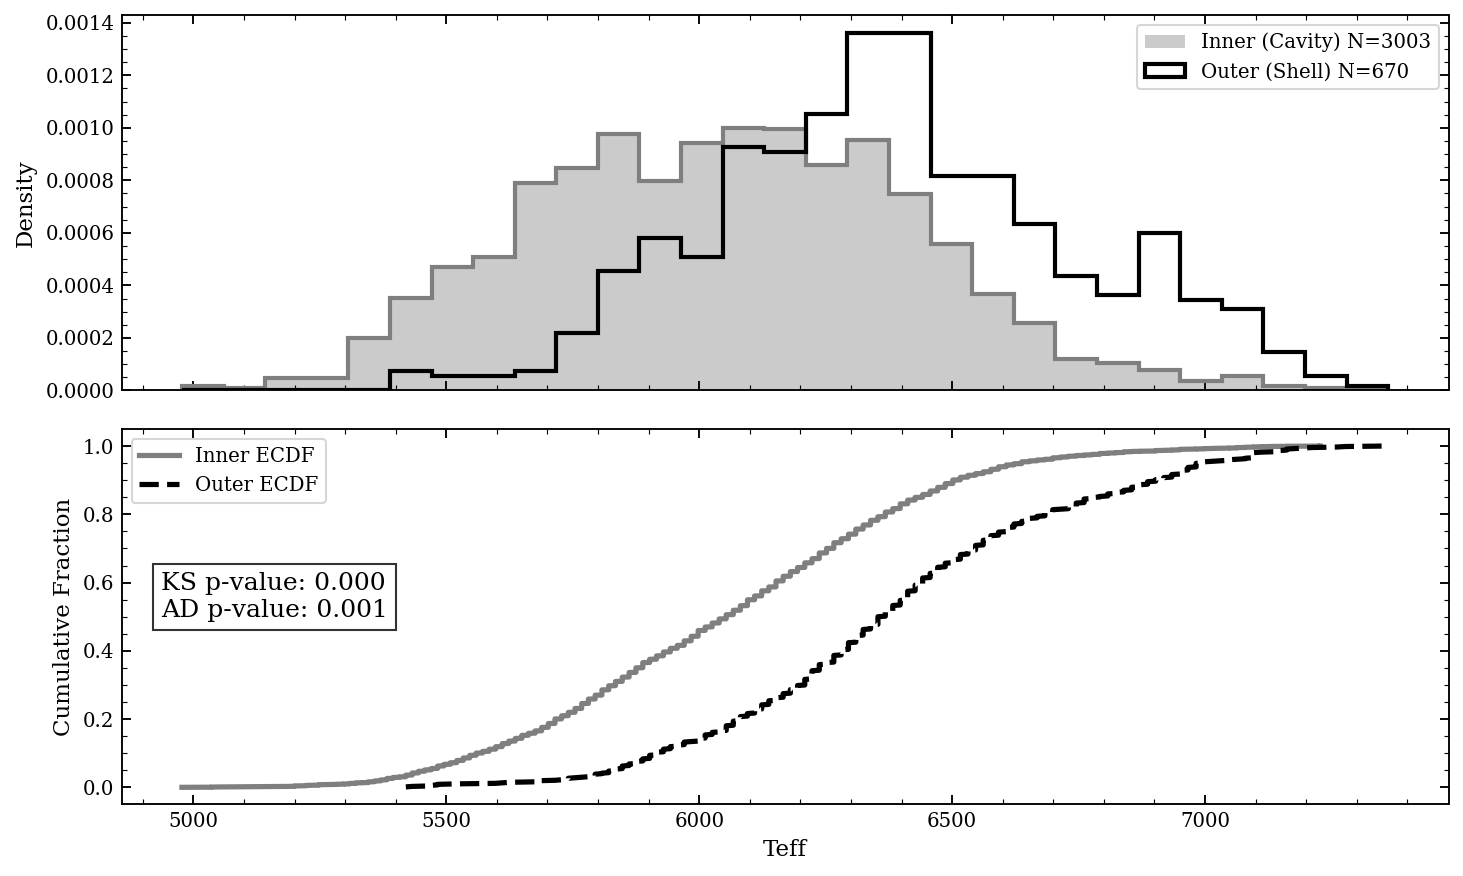

########## F STARS ##########
--- Samples ---
Cavity (R <= 80 pc): 1724 stars
Shell  (R >  80 pc): 542 stars

--- Kolmogorov-Smirnov (KS) Test ---
Statistic: 0.2520
P-value:   1.5937e-23
>> Result: Reject H0 (distributions are DIFFERENT).

--- Anderson-Darling (AD) Test ---
Statistic: 105.9013
P-value:   1.0000e-03
>> Result: Reject H0 (distributions are DIFFERENT).


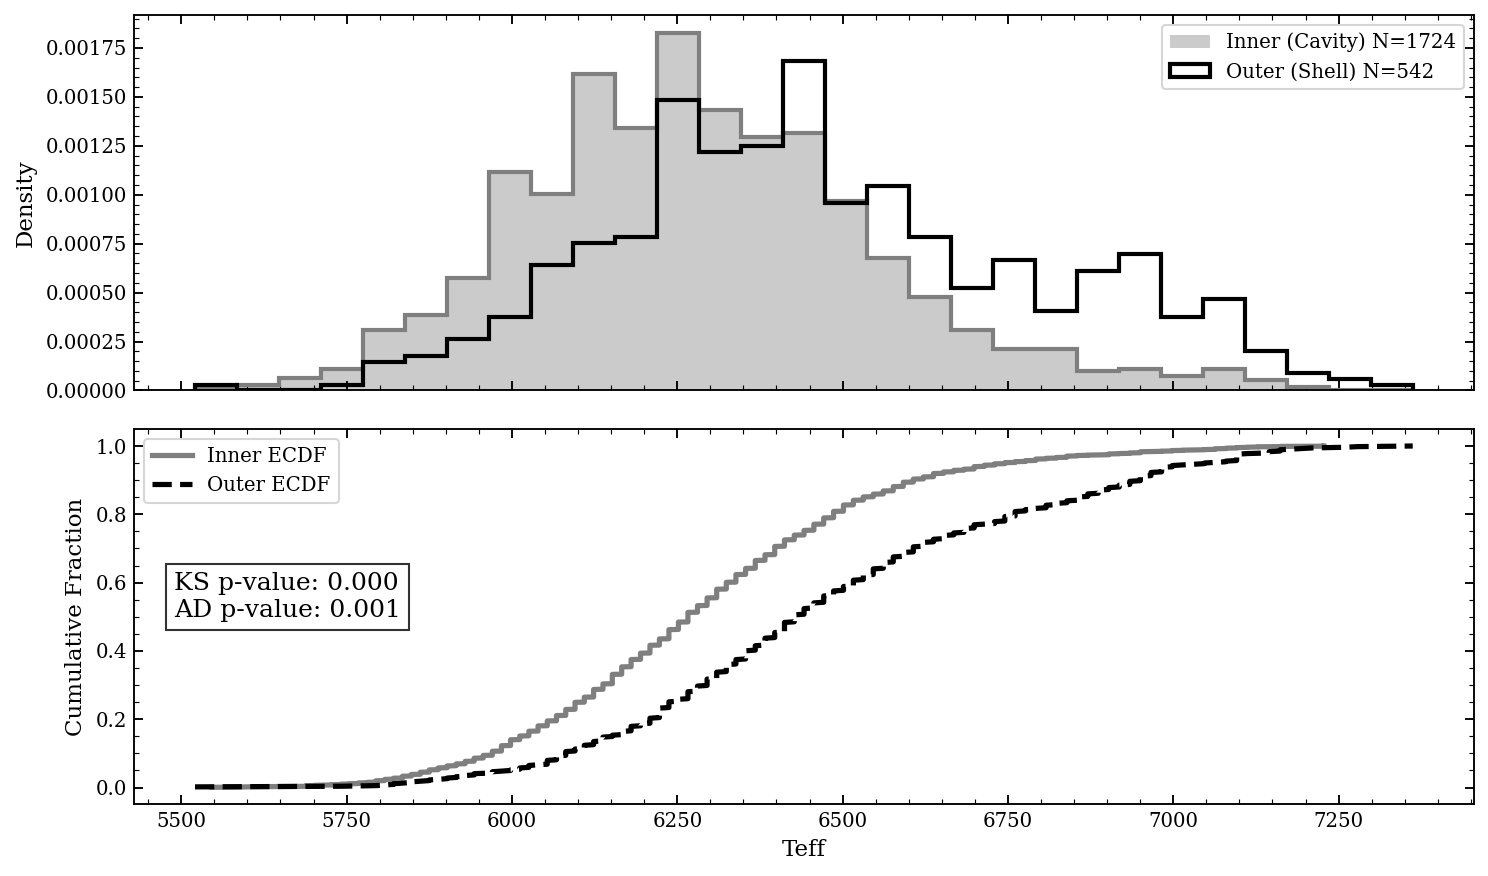

########## G STARS ##########
--- Samples ---
Cavity (R <= 80 pc): 1279 stars
Shell  (R >  80 pc): 128 stars

--- Kolmogorov-Smirnov (KS) Test ---
Statistic: 0.4591
P-value:   7.5277e-23
>> Result: Reject H0 (distributions are DIFFERENT).

--- Anderson-Darling (AD) Test ---
Statistic: 94.0547
P-value:   1.0000e-03
>> Result: Reject H0 (distributions are DIFFERENT).


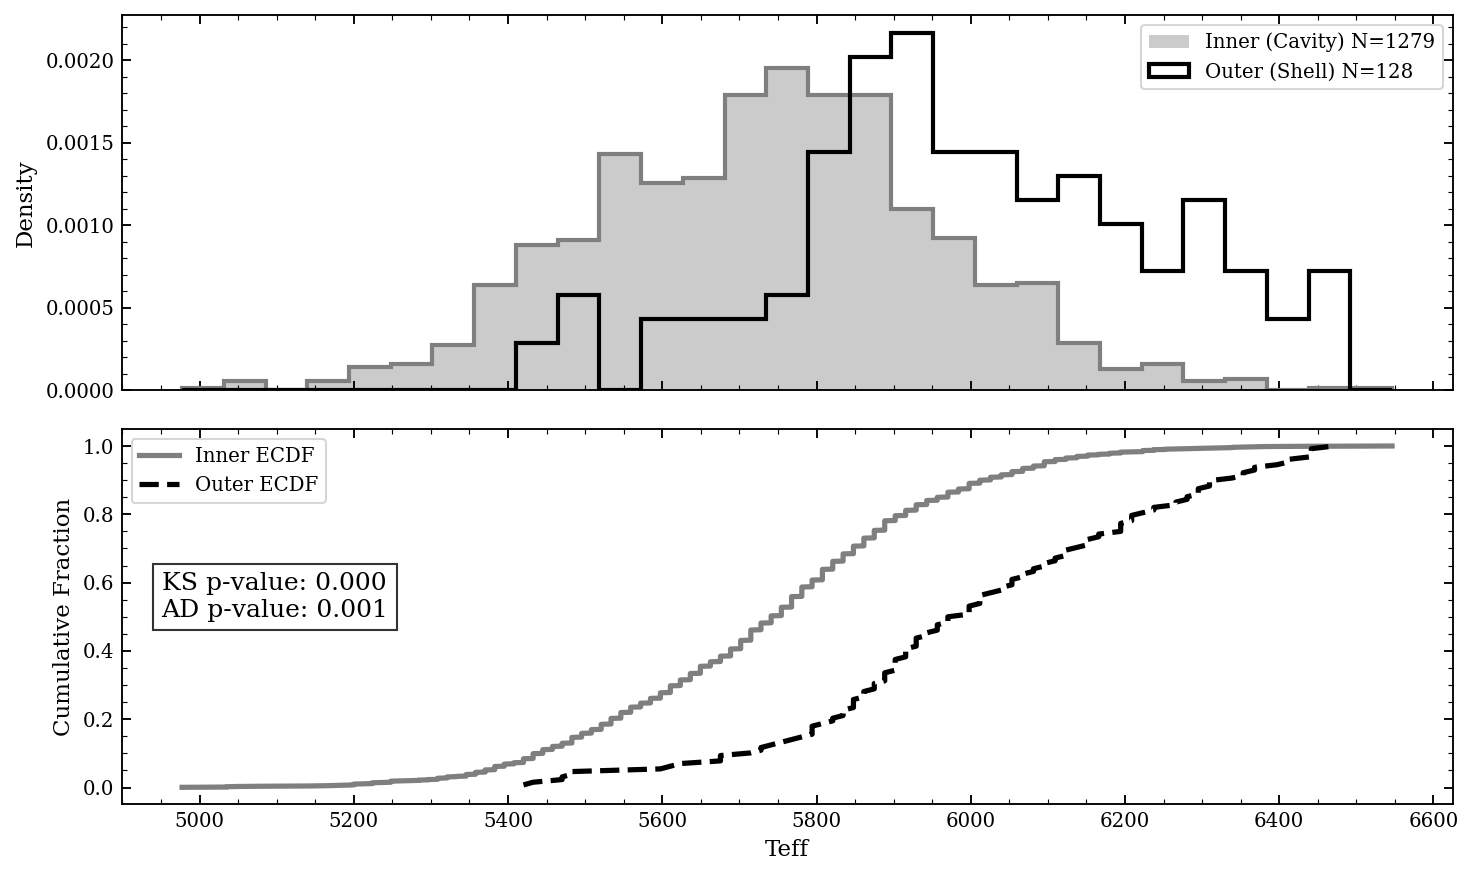

In [23]:
def compare_populations_stats(df, value_col="Teff", radius_col="R_xy", cut_radius=80):
    """
    Compares the distributions of a physical property (e.g., Teff) inside vs. outside
    a defined radius using KS and Anderson-Darling tests.
    """

    inner_mask = df[radius_col] <= cut_radius
    outer_mask = df[radius_col] > cut_radius

    data_inner = df.loc[inner_mask, value_col].dropna().values
    data_outer = df.loc[outer_mask, value_col].dropna().values

    n_inner = len(data_inner)
    n_outer = len(data_outer)

    print("--- Samples ---")
    print(f"Cavity (R <= {cut_radius} pc): {n_inner} stars")
    print(f"Shell  (R >  {cut_radius} pc): {n_outer} stars")

    ks_stat, ks_p = ks_2samp(data_inner, data_outer)

    print("\n--- Kolmogorov-Smirnov (KS) Test ---")
    print(f"Statistic: {ks_stat:.4f}")
    print(f"P-value:   {ks_p:.4e}")
    if ks_p > 0.05:
        print(">> Result: Cannot reject H0 (distributions are INDISTINGUISHABLE).")
    else:
        print(">> Result: Reject H0 (distributions are DIFFERENT).")

    ad_stat, ad_crit_vals, ad_p = anderson_ksamp([data_inner, data_outer])

    print("\n--- Anderson-Darling (AD) Test ---")
    print(f"Statistic: {ad_stat:.4f}")
    print(f"P-value:   {ad_p:.4e}")

    if ad_p > 0.05:
        print(">> Result: Cannot reject H0 (distributions are INDISTINGUISHABLE).")
    else:
        print(">> Result: Reject H0 (distributions are DIFFERENT).")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    c_in = "tab:gray"
    c_out = "black"

    bins = np.linspace(
        min(data_inner.min(), data_outer.min()),
        max(data_inner.max(), data_outer.max()),
        30,
    )

    ax1.hist(
        data_inner,
        bins=bins,
        density=True,
        histtype="stepfilled",
        alpha=0.4,
        color=c_in,
        label=f"Inner (Cavity) N={n_inner}",
    )
    ax1.hist(data_inner, bins=bins, density=True, histtype="step", lw=2, color=c_in)
    ax1.hist(
        data_outer,
        bins=bins,
        density=True,
        histtype="step",
        lw=2,
        color=c_out,
        label=f"Outer (Shell) N={n_outer}",
    )
    ax1.set_ylabel("Density")
    ax1.legend()

    x_in = np.sort(data_inner)
    y_in = np.arange(1, n_inner + 1) / n_inner
    x_out = np.sort(data_outer)
    y_out = np.arange(1, n_outer + 1) / n_outer

    ax2.plot(x_in, y_in, color=c_in, lw=2.5, label="Inner ECDF")
    ax2.plot(x_out, y_out, color=c_out, lw=2.5, linestyle="--", label="Outer ECDF")

    stats_text = f"KS p-value: {ks_p:.3f}\nAD p-value: {ad_p:.3f}"
    ax2.text(
        0.03,
        0.5,
        stats_text,
        transform=ax2.transAxes,
        bbox=dict(facecolor="white", alpha=0.8),
    )

    ax2.set_xlabel(f"{value_col}")
    ax2.set_ylabel("Cumulative Fraction")
    ax2.legend()

    plt.tight_layout()
    plt.show()


ALL["R_xy"] = np.sqrt(ALL["X"] ** 2 + ALL["Y"] ** 2)
F["R_xy"] = np.sqrt(F["X"] ** 2 + F["Y"] ** 2)
G["R_xy"] = np.sqrt(G["X"] ** 2 + G["Y"] ** 2)

ALL["Teff"] = 10 ** ALL["logTe"]
F["Teff"] = 10 ** F["logTe"]
G["Teff"] = 10 ** G["logTe"]


print("########## ALL STARS ##########")
compare_populations_stats(ALL, value_col="Teff", radius_col="R_xy", cut_radius=80)

print("########## F STARS ##########")
compare_populations_stats(F, value_col="Teff", radius_col="R_xy", cut_radius=80)

print("########## G STARS ##########")
compare_populations_stats(G, value_col="Teff", radius_col="R_xy", cut_radius=80)

We compared the effective temperature distributions inside the cavity ($R \le 80$ pc) and in the surrounding shell ($R > 80$ pc). Both the KS and AD tests strongly reject the null hypothesis that the two populations are drawn from the same distribution. The outer sample is systematically skewed toward higher $T_{\rm eff}$ (hotter, intrinsically brighter F-type stars), as the survey's magnitude limit progressively excludes cooler, fainter G-type stars at larger distances. This result directly motivates the use of the stratified permutation test.

# Randomization/forward-modelling tests

## Global Permutation Test

/tmp/ipykernel_67982/4242801056.py:133: RuntimeWarning: invalid value encountered in divide
  shape = (ci2 - boot_mean) / (boot_mean - ci1)


RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

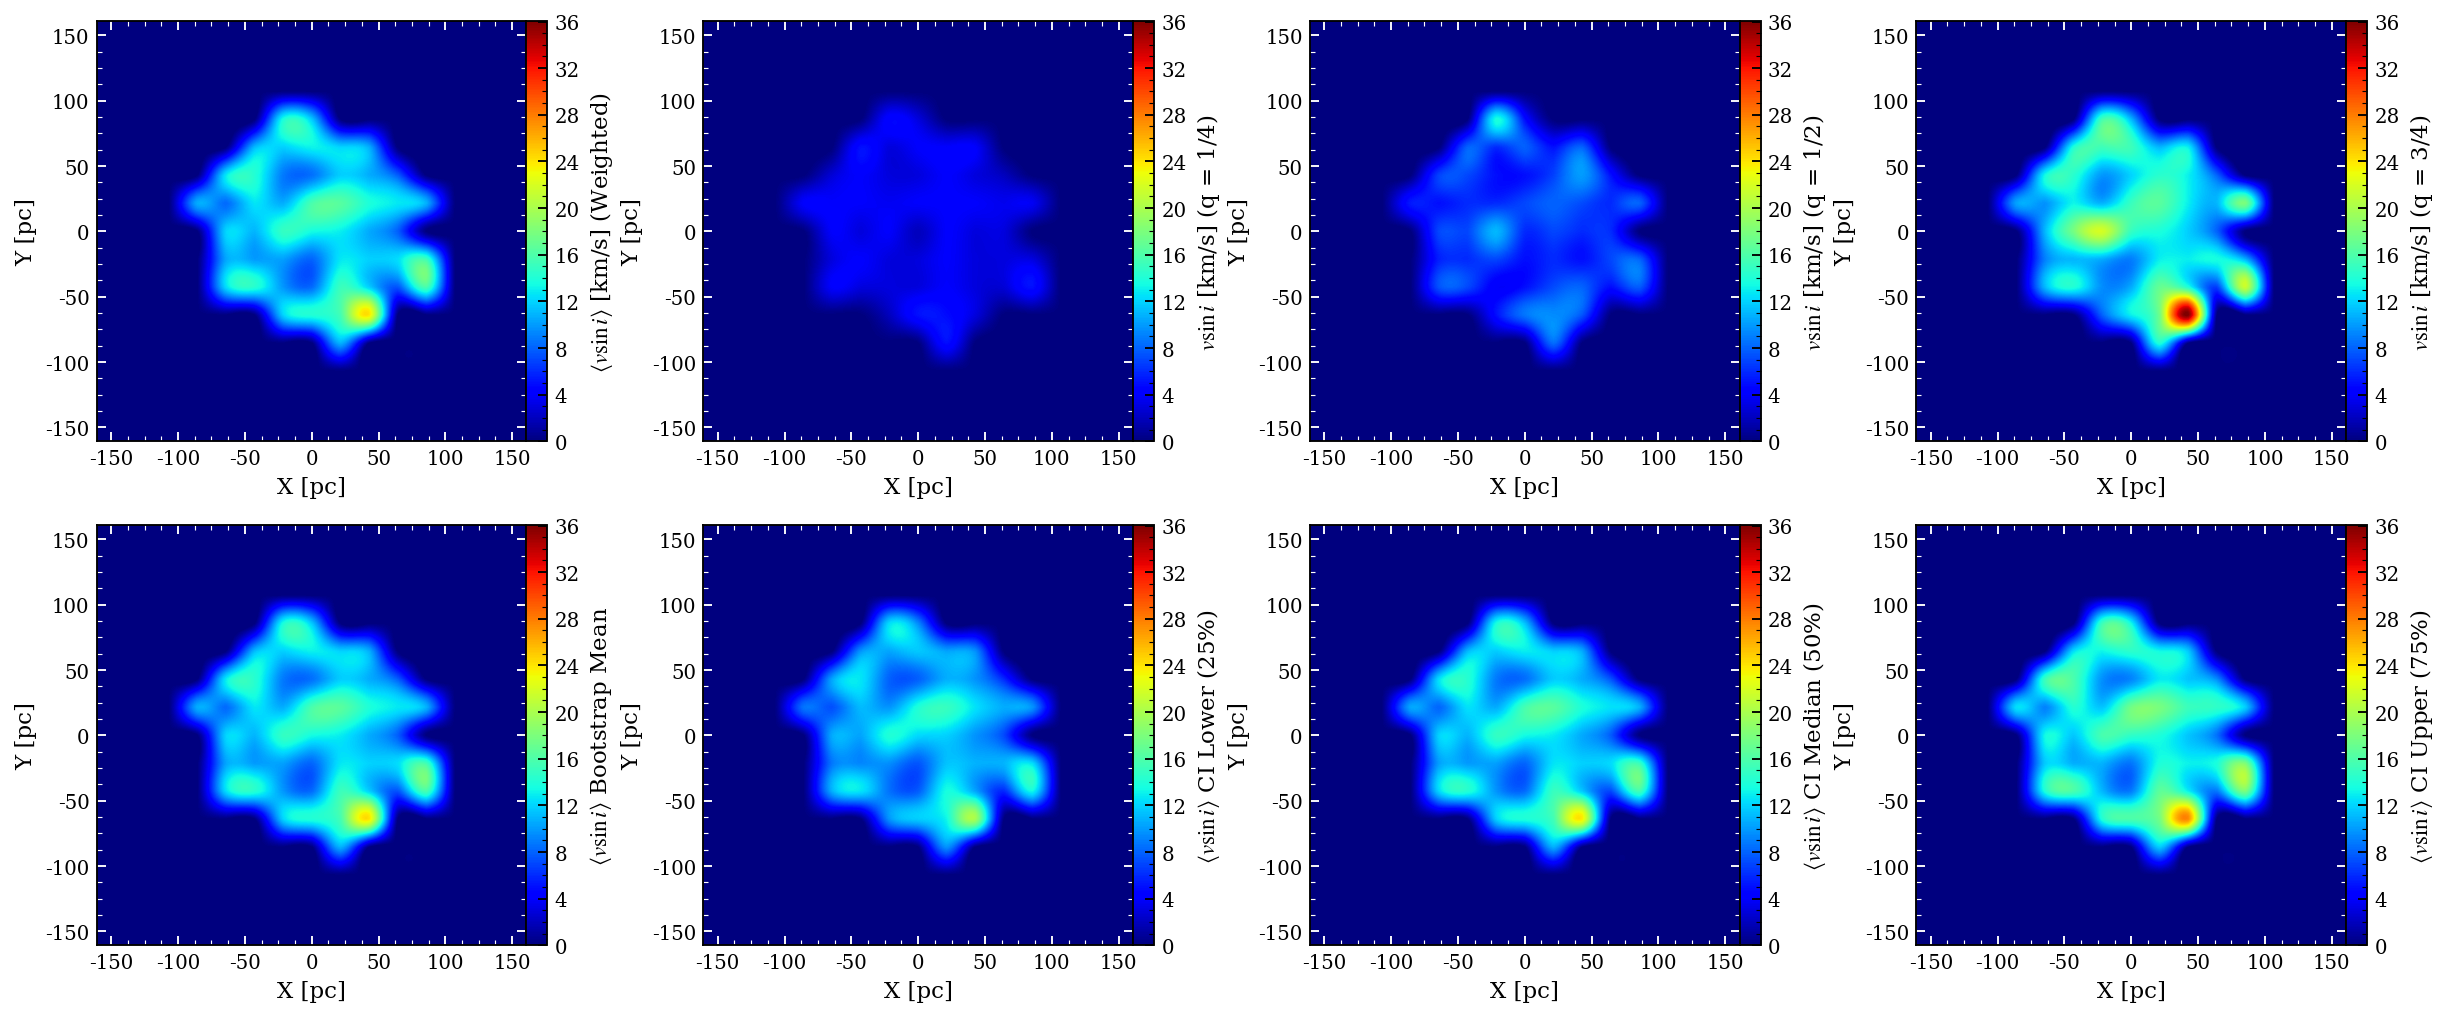

In [24]:
df_shuffled = ALL.copy()
df_shuffled["vsini"] = np.random.permutation(ALL["vsini"].values)
shuffled_xy_all = compute_vsini_bootstrap_maps(
    df_shuffled, "XY", UL=UL, INTERVAL=INTERVAL, TC=TC, B=B, ALPHA=ALPHA
)

The purpose of this test is to answer one question: Is the low-velocity cavity we see truly real, or is it just a visual artifact arising from the inherent noisiness of sparse spatial sampling?

To answer this, we perform a Monte Carlo randomization test. We create 5,000 synthetic "false universes" by randomly shuffling the vsini values across all stars. Crucially, we keep the spatial positions (X, Y) and the 1/Vmax weights fixed. This preserves the survey geometry and all selection effects, but destroys any physical correlation between rotation and position. If the observed cavity is real, virtually none of the random shuffles should produce a signal as strong as what we see in the data.

In [ ]:
def monte_carlo_cavity_test(df, iterations=5000, r_cut=80):
    """
    Performs a Monte Carlo randomization test (Forward-Modelling) to quantify
    the statistical significance of the kinematic cavity.
    """

    if "R_xy" not in df.columns:
        df = df.copy()
        df["R_xy"] = np.sqrt(df["X"] ** 2 + df["Y"] ** 2)

    mask_in = (df["R_xy"] <= r_cut).values
    mask_out = (df["R_xy"] > r_cut).values

    w_in = df.loc[mask_in, "w_vmax"].values
    w_out = df.loc[mask_out, "w_vmax"].values

    values_to_shuffle = df["vsini"].values.copy()

    m_in_real = np.average(df.loc[mask_in, "vsini"], weights=w_in)
    m_out_real = np.average(df.loc[mask_out, "vsini"], weights=w_out)

    obs_diff = m_out_real - m_in_real

    print(f"--- Observed Difference: {obs_diff:.2f} km/s ---")

    fake_diffs = np.zeros(iterations)
    print(f"Running {iterations} permutations...")

    for i in range(iterations):
        shuffled_v = np.random.permutation(values_to_shuffle)
        m_in_fake = np.average(shuffled_v[mask_in], weights=w_in)
        m_out_fake = np.average(shuffled_v[mask_out], weights=w_out)
        fake_diffs[i] = m_out_fake - m_in_fake

    p_value = np.sum(fake_diffs >= obs_diff) / iterations

    mean_fake = np.mean(fake_diffs)
    std_fake = np.std(fake_diffs)
    z_score = (obs_diff - mean_fake) / std_fake

    print(f"--- Monte Carlo Statistics ---")
    print(f"Expected Null Mean: {mean_fake:.4f} km/s")
    print(f"Null Std Dev:       {std_fake:.4f} km/s")
    print(f"Z-score:            {z_score:.2f} sigma")

    fig, ax = plt.subplots(figsize=(10, 3))

    ax.hist(
        fake_diffs,
        bins=40,
        color="lightgray",
        edgecolor="gray",
        label="Randomized Dist. (Uncorrelated)",
        histtype="stepfilled",
        density=True,
    )
    ax.axvline(obs_diff, color="tab:red", lw=3, label="Observed Signal")

    x_range = np.linspace(min(fake_diffs), max(fake_diffs), 100)
    ax.plot(
        x_range,
        norm.pdf(x_range, mean_fake, std_fake),
        "k--",
        alpha=0.6,
        label="Expected Noise Fit",
    )

    p_text = f"< {1/iterations:.5f}" if p_value == 0 else f"= {p_value:.5f}"

    stats_text = (
        f"Iterations: {iterations}\n"
        f"Observed $\\Delta v$: {obs_diff:.2f} km/s\n"
        f"Expected (Null): {mean_fake:.2f} $\\pm$ {std_fake:.2f} km/s\n"
        f"Significance: {z_score:.1f}$\\sigma$\n"
        f"p-value {p_text}"
    )

    ax.text(
        0.51,
        0.6,
        stats_text,
        transform=ax.transAxes,
        verticalalignment="top",
        horizontalalignment="left",
        fontsize=12,
    )

    ax.set_xlabel(r"Velocity Contrast $\Delta v \sin i$ (Shell - Cavity) [km/s]")
    ax.set_ylabel("Probability Density")
    ax.legend(loc="center", fontsize=12, bbox_to_anchor=(0.7, 0.8), frameon=False)
    plt.show()

    return p_value, z_score


p, z = monte_carlo_cavity_test(ALL, iterations=5000)

In [ ]:
p, z

To conclusively demonstrate that the observed low-velocity cavity is not a trivial artifact arising from the interplay between the survey's magnitude limit and the intrinsic spatial variation of stellar populations, we employed a stratified permutation test.

## Stratified Permutation Test by Effective Temperature

The reason for using the stratified version is not to introduce additional uncertain parameters. It is precisely the opposite: it is to remove a known, well-characterized source of bias. The stratified test provides a more honest and conservative answer by accounting for the fact that the F/G population ratio changes with distance.

In [ ]:
def vsini_fg_along_distance(
    d,
    dist_col="Dist",
    vsini_col="vsini",
    w_col=None,
    n_dist_bins=12,
    min_per_bin=15,
    use_quantile_bins=True,
):

    cols = ["SpecType", dist_col, vsini_col]
    if w_col is not None and w_col in d.columns:
        cols.append(w_col)

    d = d[cols].copy()

    if use_quantile_bins:
        d["Dist_bin"] = pd.qcut(d[dist_col], q=n_dist_bins, duplicates="drop")
    else:
        d["Dist_bin"] = pd.cut(d[dist_col], bins=n_dist_bins, include_lowest=True)

    g = d.groupby(["SpecType", "Dist_bin"], observed=True)

    def wmean(x):
        if w_col is None or w_col not in d.columns:
            return float(np.mean(x))
        w = d.loc[x.index, w_col].to_numpy()
        if not np.all(np.isfinite(w)) or np.sum(w) <= 0:
            return float(np.mean(x))
        return float(np.average(x.to_numpy(), weights=w))

    summary = (
        g[vsini_col]
        .agg(
            n="count",
            vsini_mean="mean",
            vsini_median="median",
            vsini_q25=lambda x: float(x.quantile(0.25)),
            vsini_q75=lambda x: float(x.quantile(0.75)),
            vsini_wmean=wmean,
        )
        .reset_index()
    )

    summary = summary[summary["n"] >= int(min_per_bin)].copy()

    bin_mid = (
        d.groupby("Dist_bin", observed=True)[dist_col]
        .median()
        .rename("dist_mid")
        .reset_index()
    )

    summary = summary.merge(bin_mid, on="Dist_bin", how="left")
    summary = summary.sort_values(["SpecType", "dist_mid"]).reset_index(drop=True)

    for sp in ["F", "G"]:
        ssp = summary[summary["SpecType"] == sp]
        if ssp.empty:
            continue

        fig, ax = plt.subplots(figsize=(10, 4))

        x = ssp["dist_mid"].to_numpy()
        y = ssp["vsini_median"].to_numpy()
        y25 = ssp["vsini_q25"].to_numpy()
        y75 = ssp["vsini_q75"].to_numpy()
        n = ssp["n"].to_numpy()

        ax.fill_between(x, y25, y75, alpha=0.2, label="IQR (25-75%)")
        ax.plot(x, y, marker="o", linewidth=2, label="Median vsini")

        if w_col is not None and "vsini_wmean" in ssp.columns:
            yw = ssp["vsini_wmean"].to_numpy()
            ax.plot(
                x,
                yw,
                marker="s",
                linewidth=1.5,
                linestyle="--",
                label="Weighted mean vsini",
            )

        ax.set_xlabel(f"Distance ({dist_col})")
        ax.set_ylabel(r"$v\sin i$ [km s$^{-1}$]")
        ax.set_title(f"{sp}-type stars: $v\\sin i$ distribution along distance bins")
        ax.legend(loc="upper left")
        plt.show()

    for sp in ["F", "G"]:
        d_sp = d[d["SpecType"] == sp].copy()
        if d_sp.empty:
            continue

        bins_sorted = (
            d_sp.groupby("Dist_bin", observed=True)[dist_col]
            .median()
            .sort_values()
            .index.tolist()
        )
        data = [
            d_sp.loc[d_sp["Dist_bin"] == b, vsini_col].to_numpy() for b in bins_sorted
        ]

        _, ax = plt.subplots(figsize=(10, 4))
        ax.boxplot(data, showfliers=False)

        tick_labels = []
        for b in bins_sorted:
            left = getattr(b, "left", np.nan)
            right = getattr(b, "right", np.nan)
            if np.isfinite(left) and np.isfinite(right):
                tick_labels.append(f"{left:.0f}-{right:.0f}")
            else:
                tick_labels.append(str(b))

        ax.set_xticks(np.arange(1, len(bins_sorted) + 1))
        ax.set_xticklabels(tick_labels, rotation=45, ha="right")

        ax.set_xlabel(f"Distance bin ({dist_col})")
        ax.set_ylabel(r"$v\sin i$ [km s$^{-1}$]")
        ax.set_title(f"{sp}-type stars: $v\\sin i$ boxplots by distance bin")
        plt.show()

    return summary


summary_fg = vsini_fg_along_distance(
    ALL,
    dist_col="Dist",
    vsini_col="vsini",
    w_col="w_vmax",
    n_dist_bins=12,
    min_per_bin=15,
    use_quantile_bins=True,
)

summary_fg

In a magnitude-limited catalogue, the composition of the sample changes with distance. Within the cavity we have 3003 stars (1724 F + 1279 G, ratio F/G ≈ 1.35). In the shell we have 670 stars (542 F + 128 G, ratio F/G ≈ 4.23). Because F stars rotate faster on average, this shift in population mix alone can inflate the apparent velocity contrast between the two regions.

In [ ]:
def count_fg_in_out(
    d,
    r_cut=80.0,
    r_col="R_xy",
):
    d["Region"] = np.where(
        d[r_col].to_numpy() <= float(r_cut), "Cavity (in)", "Shell (out)"
    )

    table = (
        d.groupby(["Region", "SpecType"], observed=True).size().unstack(fill_value=0)
    )

    table["Total"] = table.sum(axis=1)
    table.loc["Total", :] = table.sum(axis=0)

    pct = table.copy().astype(float)
    pct.loc[["Cavity (in)", "Shell (out)"], ["F", "G"]] = 100 * pct.loc[
        ["Cavity (in)", "Shell (out)"], ["F", "G"]
    ].div(pct.loc[["Cavity (in)", "Shell (out)"], "Total"], axis=0)
    pct = pct.round(2)
    pct.rename(columns={"F": "F (%)", "G": "G (%)"}, inplace=True)

    return table.astype(int), pct


counts, _ = count_fg_in_out(ALL, r_cut=80.0)
counts

Thus, the idea behind the stratified approach is that, instead of shuffling $v \sin i$ across all stars, we only exchange values within the same $T_{\rm eff}$ bin. This way, in each Monte Carlo realization, the simulated universe has exactly the same temperature distribution as the real data — so any velocity difference between cavity and shell in the simulation must come from spatial variation within each temperature class, not from a shift in stellar type.

In [ ]:
def plot_teff_and_vsini_by_teff_bins(d, teff_col="Teff", vsini_col="vsini", n_bins=10):
    d["Teff_bin"] = pd.qcut(d[teff_col], q=n_bins, labels=False, duplicates="drop")
    n_eff = int(d["Teff_bin"].max()) + 1

    teff_data = [d.loc[d["Teff_bin"] == b, teff_col].to_numpy() for b in range(n_eff)]
    vsini_data = [d.loc[d["Teff_bin"] == b, vsini_col].to_numpy() for b in range(n_eff)]

    _, ax = plt.subplots(figsize=(10, 4))
    ax.boxplot(teff_data, showfliers=False)
    ax.set_xlabel("Teff bin (quantiles)")
    ax.set_ylabel("Teff [K]")
    ax.ticklabel_format(style="plain", axis="y")
    ax.set_xticks(np.arange(1, n_eff + 1))
    ax.set_xticklabels([str(b) for b in range(n_eff)])
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.boxplot(vsini_data, showfliers=False)
    ax.set_xlabel("Teff bin (quantiles)")
    ax.set_ylabel(r"$v\sin i$ [km s$^{-1}$]")
    ax.set_xticks(np.arange(1, n_eff + 1))
    ax.set_xticklabels([str(b) for b in range(n_eff)])
    plt.show()

    summary = (
        d.groupby("Teff_bin")
        .agg(
            n=(teff_col, "count"),
            Teff_min=(teff_col, "min"),
            Teff_med=(teff_col, "median"),
            Teff_max=(teff_col, "max"),
            vsini_med=(vsini_col, "median"),
            vsini_mean=(vsini_col, "mean"),
            vsini_std=(vsini_col, "std"),
        )
        .reset_index()
    )
    return summary


# F-stars
plot_teff_and_vsini_by_teff_bins(F, teff_col="Teff", vsini_col="vsini", n_bins=10)

In [ ]:
# G stars
plot_teff_and_vsini_by_teff_bins(G, teff_col="Teff", vsini_col="vsini", n_bins=10)

In each Monte Carlo realization, $v \sin i$ is shuffled only within its respective bin, while $T_{\mathrm{eff}}$ and the spatial positions remain fixed. This produces a null distribution of velocity contrasts that accounts for the demographic composition of the cavity versus the shell.

In [ ]:
def monte_carlo_stratified_teff(d, iterations=10000, r_cut=80.0, n_bins=10, seed=42):
    mask_in = d["R_xy"].to_numpy() <= float(r_cut)
    mask_out = ~mask_in

    w_in = d.loc[mask_in, "w_vmax"].to_numpy()
    w_out = d.loc[mask_out, "w_vmax"].to_numpy()

    teff_bins = pd.qcut(d["Teff"], q=int(n_bins), labels=False, duplicates="drop")
    d["teff_bin"] = teff_bins.astype(int)
    n_eff = int(d["teff_bin"].max()) + 1

    vsini_original = d["vsini"].to_numpy()

    m_in_real = np.average(vsini_original[mask_in], weights=w_in)
    m_out_real = np.average(vsini_original[mask_out], weights=w_out)
    obs_diff = float(m_out_real - m_in_real)

    rng = np.random.default_rng(seed)
    fake_diffs = np.empty(iterations, dtype=float)

    bin_indices = [np.where(d["teff_bin"].to_numpy() == b)[0] for b in range(n_eff)]

    for i in range(iterations):
        shuffled_v = vsini_original.copy()
        for idx in bin_indices:
            if idx.size < 2:
                continue
            shuffled_v[idx] = rng.permutation(shuffled_v[idx])

        m_in_fake = np.average(shuffled_v[mask_in], weights=w_in)
        m_out_fake = np.average(shuffled_v[mask_out], weights=w_out)
        fake_diffs[i] = float(m_out_fake - m_in_fake)

    mean_fake = float(np.mean(fake_diffs))
    std_fake = float(np.std(fake_diffs, ddof=0))

    k_extreme = int(np.sum(fake_diffs >= obs_diff))
    p_value = (k_extreme + 1) / (iterations + 1)

    z_score = float((obs_diff - mean_fake) / std_fake) if std_fake > 0 else np.inf

    _, ax = plt.subplots(figsize=(10, 3))

    ax.hist(
        fake_diffs,
        bins=40,
        color="lightgray",
        edgecolor="gray",
        label=r"Stratified Dist. ($T_{\rm eff}$-constrained)",
        histtype="stepfilled",
        density=True,
    )

    ax.axvline(obs_diff, color="tab:red", lw=3, label="Observed Signal")

    x_range = np.linspace(float(np.min(fake_diffs)), float(np.max(fake_diffs)), 200)
    ax.plot(
        x_range,
        norm.pdf(x_range, mean_fake, std_fake),
        "k--",
        alpha=0.6,
        label="Expected Noise Fit",
    )

    p_text = f"< {1/(iterations+1):.5f}" if k_extreme == 0 else f"= {p_value:.5f}"

    stats_text = (
        f"Bins: {n_eff} (Quantiles)\n"
        f"Iterations: {iterations}\n"
        f"Observed \u0394v: {obs_diff:.2f} km/s\n"
        f"Expected (Null): {mean_fake:.2f} \u00b1 {std_fake:.2f} km/s\n"
        f"Significance: {z_score:.1f}\u03c3\n"
        f"p-value {p_text}"
    )

    ax.text(
        0.02, 0.65, stats_text, transform=ax.transAxes, va="top", ha="left", fontsize=11
    )
    ax.set_xlabel(r"Velocity Contrast $\Delta v\sin i$ (Shell \u2212 Cavity) [km/s]")
    ax.set_ylabel("Probability Density")
    ax.legend(loc="center", fontsize=11, bbox_to_anchor=(0.2, 0.8), frameon=False)

    plt.show()

    return {
        "p_value": p_value,
        "z_score": z_score,
        "obs_diff": obs_diff,
        "mean_null": mean_fake,
        "std_null": std_fake,
        "iterations": iterations,
        "seed": seed,
        "r_cut": float(r_cut),
        "n_bins_requested": int(n_bins),
        "n_bins_effective": int(n_eff),
        "k_extreme": k_extreme,
    }, fake_diffs


res, fake = monte_carlo_stratified_teff(
    ALL, iterations=10000, n_bins=10, r_cut=80.0, seed=42
)
res

A potential concern is that the observed velocity contrast could be driven solely by the radial variation in the stellar population mix (the demographic hypothesis), rather than by a genuine kinematic anomaly. The stratified test addresses this directly.

In [ ]:
def _plane_xy(df, plane):
    if plane == "XY":
        return df["X"].to_numpy(), df["Y"].to_numpy()
    if plane == "XZ":
        return df["X"].to_numpy(), df["Z"].to_numpy()
    if plane == "ZY":
        return df["Z"].to_numpy(), df["Y"].to_numpy()
    raise ValueError("plane must be 'XY', 'XZ', or 'ZY'.")


def compute_residual_map_fast(
    df,
    plane="XY",
    ul=150,
    tc=20,
    interval=1,
    iterations=200,
    n_bins=10,
    min_count=10,
    seed=42,
    progress_every=100,
    return_components=False,
):
    rng = np.random.default_rng(seed)
    x, y = _plane_xy(df, plane)
    vsini = df["vsini"].to_numpy()
    w = df["w_vmax"].to_numpy()
    teff = df["Teff"].to_numpy()

    step = interval * tc
    edges = np.arange(-ul, ul + step, step)
    Nx = len(edges) - 1
    Ny = len(edges) - 1

    in_box = (x >= -ul) & (x < ul) & (y >= -ul) & (y < ul)
    x, y, vsini, w, teff = x[in_box], y[in_box], vsini[in_box], w[in_box], teff[in_box]

    ix = np.floor((x + ul) / step).astype(int)
    iy = np.floor((y + ul) / step).astype(int)
    ok = (ix >= 0) & (ix < Nx) & (iy >= 0) & (iy < Ny)
    ix, iy, vsini, w, teff = ix[ok], iy[ok], vsini[ok], w[ok], teff[ok]

    flat = iy * Nx + ix
    n_cells = Nx * Ny
    count_cell = np.bincount(flat, minlength=n_cells).astype(float)
    sumw_cell = np.bincount(flat, weights=w, minlength=n_cells).astype(float)
    valid_cells = (count_cell >= min_count) & (sumw_cell > 0)

    def grid_mean(v_data):
        sumwv = np.bincount(flat, weights=w * v_data, minlength=n_cells).astype(float)
        out = np.full(n_cells, np.nan, dtype=float)
        out[valid_cells] = sumwv[valid_cells] / sumw_cell[valid_cells]
        return out.reshape(Ny, Nx)

    map_obs = grid_mean(vsini)
    teff_bins = pd.qcut(teff, q=n_bins, labels=False, duplicates="drop")
    bins = np.unique(teff_bins[~pd.isna(teff_bins)])
    bin_idx = [np.where(teff_bins == b)[0] for b in bins]

    acc = np.zeros((Ny, Nx), dtype=float)
    for k in range(iterations):
        shuffled = np.empty_like(vsini)
        for idx in bin_idx:
            shuffled[idx] = rng.permutation(vsini[idx])
        acc += grid_mean(shuffled)

    map_exp = acc / float(iterations)
    map_res = map_obs - map_exp

    if return_components:
        return map_obs, map_exp, map_res
    return map_res


def plot_residuals_styled_3planes(
    residuals_by_plane, ul, method="spline36", cmap_res="bwr"
):
    fig, axs = plt.subplots(1, 3, figsize=(20, 5.8))
    planes = ("XY", "XZ", "ZY")
    all_maps = [residuals_by_plane[p] for p in planes]
    limit = np.nanmax([np.nanmax(np.abs(m)) for m in all_maps])

    for ax, plane, data_array in zip(axs, planes, all_maps):
        Ny, Nx = data_array.shape
        x_grid = np.arange(Nx)
        y_grid = np.arange(Ny)
        xnew = np.linspace(0, Nx - 1, Nx)
        ynew = np.linspace(0, Ny - 1, Ny)

        temp = (
            np.nan_to_num(data_array, nan=np.nanmean(data_array))
            if np.isnan(data_array).any()
            else data_array
        )
        spline = RectBivariateSpline(x_grid, y_grid, temp.T, kx=3, ky=3)
        ima = spline(xnew, ynew)

        cax = ax.imshow(
            ima.T,
            cmap=plt.get_cmap(cmap_res),
            aspect="auto",
            origin="lower",
            interpolation=method,
            vmin=-limit,
            vmax=limit,
        )
        cbar = fig.colorbar(cax, ax=ax, pad=0)
        cbar.set_label(r"$\Delta v\sin i$ (Obs - Exp) [km/s]")
        cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))

        xlabel = {"XY": "X [pc]", "XZ": "X [pc]", "ZY": "Z [pc]"}[plane]
        ylabel = {"XY": "Y [pc]", "XZ": "Z [pc]", "ZY": "Y [pc]"}[plane]
        ax.set_title(f"Residual ({plane})", pad=10)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        ticklabels = np.arange(-ul, ul + 1, 50)
        xticks = np.linspace(0, ima.shape[1] - 1, len(ticklabels))
        yticks = np.linspace(0, ima.shape[0] - 1, len(ticklabels))
        ax.set_xticks(xticks)
        ax.set_xticklabels(ticklabels)
        ax.set_yticks(yticks)
        ax.set_yticklabels(ticklabels)

        scale_factor = (ima.shape[1] - 1) / (2 * ul)
        pixel_radius = 80 * scale_factor
        pixel_center_x = (ima.shape[1] - 1) / 2
        pixel_center_y = (ima.shape[0] - 1) / 2
        circle = plt.Circle(
            (pixel_center_x, pixel_center_y),
            pixel_radius,
            color="black",
            fill=False,
            linestyle="--",
            lw=2,
            alpha=0.6,
        )
        ax.add_patch(circle)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.25)
    plt.show()


residuals = {
    p: compute_residual_map_fast(
        ALL,
        ul=150,
        tc=20,
        interval=1,
        iterations=10000,
        n_bins=10,
        min_count=10,
        seed=42,
        progress_every=250,
        plane=p,
    )
    for p in ("XY", "XZ", "ZY")
}

plot_residuals_styled_3planes(residuals, ul=150, method="spline36", cmap_res="seismic")

In [ ]:
def scan_cavity_robustness(df, radii_range, iterations=500, n_bins=10, seed=42):
    results = []
    rng = np.random.default_rng(seed)
    df = df.copy()
    df["teff_bin"] = pd.qcut(df["Teff"], q=n_bins, labels=False, duplicates="drop")
    vsini_original = df["vsini"].to_numpy()
    teff_bin = df["teff_bin"].to_numpy()
    unique_bins = np.unique(teff_bin[~pd.isna(teff_bin)])
    bin_indices = [np.where(teff_bin == b)[0] for b in unique_bins]

    for r in radii_range:
        mask_in = df["R_xy"].to_numpy() <= r
        mask_out = ~mask_in
        n_in = int(mask_in.sum())
        n_out = int(mask_out.sum())
        if n_in < 20 or n_out < 20:
            continue

        w_in = df.loc[mask_in, "w_vmax"].to_numpy()
        w_out = df.loc[mask_out, "w_vmax"].to_numpy()

        m_in_real = np.average(df.loc[mask_in, "vsini"].to_numpy(), weights=w_in)
        m_out_real = np.average(df.loc[mask_out, "vsini"].to_numpy(), weights=w_out)
        obs_diff = m_out_real - m_in_real

        fake_diffs = np.empty(iterations, dtype=float)
        for it in range(iterations):
            shuffled_v = np.empty_like(vsini_original)
            for idx in bin_indices:
                shuffled_v[idx] = rng.permutation(vsini_original[idx])
            m_in_fake = np.average(shuffled_v[mask_in], weights=w_in)
            m_out_fake = np.average(shuffled_v[mask_out], weights=w_out)
            fake_diffs[it] = m_out_fake - m_in_fake

        mean_expected = float(np.mean(fake_diffs))
        std_expected = float(np.std(fake_diffs, ddof=1))
        residual = float(obs_diff - mean_expected)
        z_score = float(residual / std_expected) if std_expected > 0 else np.nan
        p_two_sided = float(
            (np.sum(np.abs(fake_diffs - mean_expected) >= abs(residual)) + 1)
            / (iterations + 1)
        )

        results.append(
            {
                "Radius": float(r),
                "Observed": float(obs_diff),
                "Expected": mean_expected,
                "Residual": residual,
                "Uncertainty": std_expected,
                "Z_score": z_score,
                "p_two_sided": p_two_sided,
                "N_in": n_in,
                "N_out": n_out,
            }
        )

    return pd.DataFrame(results)


radius = np.arange(40, 130, 10)
df_scan = scan_cavity_robustness(ALL, radius, iterations=10000, n_bins=10, seed=42)
df_scan

In [ ]:
_, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(
    df_scan["Radius"],
    df_scan["Observed"],
    "o-",
    lw=2,
    label="Observed (Shell - Cavity)",
)
ax1.errorbar(
    df_scan["Radius"],
    df_scan["Expected"],
    yerr=df_scan["Uncertainty"],
    fmt="o--",
    color="gray",
    label="Expected (Teff-stratified)",
)
ax1.fill_between(
    df_scan["Radius"],
    df_scan["Expected"],
    df_scan["Observed"],
    alpha=0.12,
    label="Residual",
)
ax1.set_ylabel(r"$\Delta \langle v\sin i\rangle$ [km/s]")
ax1.legend(loc="best")
ax1.axvline(80, color="green", linestyle=":", lw=2)

ax2.plot(df_scan["Radius"], df_scan["Z_score"], "D-", lw=2)
ax2.axhline(3.0, color="k", linestyle="--", label=r"$3\sigma$")
ax2.axhline(0.0, color="k", lw=0.6)
ax2.axvline(80, color="green", linestyle=":", lw=2)
ax2.set_xlabel("Radius cut [pc]")
ax2.set_ylabel("Z-score")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

# Spatially gridded statistics of projected rotational velocity ($v\sin i$) projected onto the Galactic **XY**, **XZ**, and **ZY** planes

In [ ]:
def calculate_plane_stats(
    data,
    plane,
    ul,
    interval,
    tc,
    min_count,
    use_weights,
    vsini_col="vsini",
    weight_col="w_vmax",
):
    if plane == "XY":
        x, y = data["X"], data["Y"]
    elif plane == "XZ":
        x, y = data["X"], data["Z"]
    elif plane == "ZY":
        x, y = data["Z"], data["Y"]
    else:
        raise ValueError("Plane must be XY, XZ, or ZY")

    vsini = data[vsini_col].values
    raw_weights = data[weight_col].values if use_weights else np.ones(len(vsini))

    step = interval * tc
    ttx = np.arange(-ul, ul + step, step)
    tty = np.arange(-ul, ul + step, step)
    Nx, Ny = len(ttx) - 1, len(tty) - 1

    mean_map = np.zeros((Ny, Nx))
    p25_map = np.zeros((Ny, Nx))
    p50_map = np.zeros((Ny, Nx))
    p75_map = np.zeros((Ny, Nx))

    for j in range(Nx):
        for i in range(Ny):
            cond = (ttx[j] <= x) & (x < ttx[j + 1]) & (tty[i] <= y) & (y < tty[i + 1])
            v_cell = vsini[cond]
            w_cell = raw_weights[cond]
            if len(v_cell) >= min_count and np.sum(w_cell) > 0:
                w_norm = w_cell / np.sum(w_cell)
                mean_map[i, j] = np.sum(v_cell * w_norm)
                if use_weights:
                    p25_map[i, j] = weighted_percentile(v_cell, w_cell, 25.0)
                    p50_map[i, j] = weighted_percentile(v_cell, w_cell, 50.0)
                    p75_map[i, j] = weighted_percentile(v_cell, w_cell, 75.0)
                else:
                    p25_map[i, j] = np.percentile(v_cell, 25.0)
                    p50_map[i, j] = np.percentile(v_cell, 50.0)
                    p75_map[i, j] = np.percentile(v_cell, 75.0)

    return {
        "Mean": mean_map,
        "Q25": p25_map,
        "Median": p50_map,
        "Q75": p75_map,
        "ttx": ttx,
        "tty": tty,
        "Nx": Nx,
        "Ny": Ny,
    }


def plot_3_planes(
    data,
    ul=150,
    interval=1,
    tc=20,
    min_count=20,
    use_weights=True,
    cmap="jet",
    method="spline16",
):
    planes = ["XY", "XZ", "ZY"]
    stats_keys = ["Mean", "Q25", "Median", "Q75"]
    fig, axs = plt.subplots(3, 4, figsize=(20, 13))
    mean_label = r"$\langle v\sin i \rangle$ [km/s]" + (
        " (Weighted)" if use_weights else " (Unweighted)"
    )
    titles = [
        mean_label,
        r"$v\sin i$ [km/s] ($q = 1/4$)",
        r"$v\sin i$ [km/s] ($q = 1/2$)",
        r"$v\sin i$ [km/s] ($q = 3/4$)",
    ]
    all_maps = []
    results_storage = {}
    for plane in planes:
        res = calculate_plane_stats(
            data, plane, ul, interval, tc, min_count, use_weights
        )
        results_storage[plane] = res
        for k in stats_keys:
            all_maps.append(res[k])
    global_vmin = 0
    valid_vals = [np.nanmax(m) for m in all_maps if np.nanmax(m) > 0]
    global_vmax = max(valid_vals) if valid_vals else 10
    for row_idx, plane in enumerate(planes):
        res = results_storage[plane]
        x_grid = np.arange(res["Nx"])
        y_grid = np.arange(res["Ny"])
        xnew = np.linspace(0, res["Nx"] - 1, res["Nx"])
        ynew = np.linspace(0, res["Ny"] - 1, res["Ny"])
        xlab, ylab = {
            "XY": ("X [pc]", "Y [pc]"),
            "XZ": ("X [pc]", "Z [pc]"),
            "ZY": ("Z [pc]", "Y [pc]"),
        }[plane]
        for col_idx, key in enumerate(stats_keys):
            ax = axs[row_idx, col_idx]
            raw_map = res[key]
            if np.any(raw_map):
                spline = RectBivariateSpline(x_grid, y_grid, raw_map.T, kx=3, ky=3)
                ima = spline(xnew, ynew)
            else:
                ima = np.zeros((res["Ny"], res["Nx"]))
            cax = ax.imshow(
                ima.T,
                cmap=plt.get_cmap(cmap),
                aspect="auto",
                origin="lower",
                interpolation=method,
                vmin=global_vmin,
                vmax=global_vmax,
            )
            xticklabels = np.arange(-ul, ul + 1, 50)
            xticks = np.linspace(0, ima.shape[1] - 1, len(xticklabels))
            yticklabels = np.arange(-ul, ul + 1, 50)
            yticks = np.linspace(0, ima.shape[0] - 1, len(yticklabels))
            ax.set_xticks(xticks)
            ax.set_xticklabels(xticklabels)
            ax.set_yticks(yticks)
            ax.set_yticklabels(yticklabels)
            ax.set_xlabel(xlab)
            if col_idx == 0:
                ax.set_ylabel(ylab)
            if row_idx == 0:
                ax.set_title(titles[col_idx], pad=10)
            cbar = fig.colorbar(cax, ax=ax, pad=0)
            cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))
            ax.tick_params(axis="both", colors="white", labelcolor="black")
    plt.subplots_adjust(wspace=0.2, hspace=0.3)
    plt.show()

## All stars unweighted

In [ ]:
plot_3_planes(ALL, ul=150, tc=20, use_weights=False)

## All stars weighted

In [ ]:
plot_3_planes(ALL, ul=150, tc=20, use_weights=True)

# F stars

In [ ]:
plot_3_planes(F, ul=150, tc=20, use_weights=True)

# G stars

In [ ]:
plot_3_planes(G, ul=150, tc=20, use_weights=True)

# Statistical significance maps

We constructed **significance maps** to quantify, in each spatial cell, how strongly the local mean projected rotation deviates from the global sample mean, expressed in units of the local standard error.

In [ ]:
def plot_significance_maps(
    data,
    ul=150,
    interval=1,
    tc=20,
    min_count=20,
    use_weights=True,
    vsini_col="vsini",
    weight_col="w_vmax",
):
    """
    Generates statistical significance (Z-score) maps for XY, XZ, and ZY.
    """
    vals_all = data[vsini_col].values
    weights_all = data[weight_col].values if use_weights else np.ones(len(vals_all))
    global_mean = np.average(vals_all, weights=weights_all)
    print(f"Global Reference Mean: {global_mean:.2f} km/s")

    fig, axs = plt.subplots(1, 3, figsize=(18, 5.5))
    planes = ["XY", "XZ", "ZY"]
    step = interval * tc
    ttx = np.arange(-ul, ul + step, step)
    tty = np.arange(-ul, ul + step, step)
    Nx, Ny = len(ttx) - 1, len(tty) - 1
    x_grid = np.arange(Nx)
    y_grid = np.arange(Ny)
    xnew = np.linspace(0, Nx - 1, Nx * 2)
    ynew = np.linspace(0, Ny - 1, Ny * 2)

    for idx, plane in enumerate(planes):
        ax = axs[idx]
        if plane == "XY":
            x, y, xlab, ylab = data["X"], data["Y"], "X [pc]", "Y [pc]"
        elif plane == "XZ":
            x, y, xlab, ylab = data["X"], data["Z"], "X [pc]", "Z [pc]"
        elif plane == "ZY":
            x, y, xlab, ylab = data["Z"], data["Y"], "Z [pc]", "Y [pc]"

        z_map = np.full((Ny, Nx), np.nan)
        for j in range(Nx):
            for i in range(Ny):
                cond = (
                    (ttx[j] <= x) & (x < ttx[j + 1]) & (tty[i] <= y) & (y < tty[i + 1])
                )
                v_cell = vals_all[cond]
                w_cell = weights_all[cond]
                n_stars = len(v_cell)
                if n_stars >= min_count and np.sum(w_cell) > 0:
                    w_norm = w_cell / np.sum(w_cell)
                    mean_local = np.sum(v_cell * w_norm)
                    var_local = np.sum(w_norm * (v_cell - mean_local) ** 2)
                    std_local = np.sqrt(var_local)
                    sem_local = std_local / np.sqrt(n_stars)
                    if sem_local > 0:
                        z_map[i, j] = (mean_local - global_mean) / sem_local

        z_map_filled = np.nan_to_num(z_map, 0)
        if np.any(z_map_filled):
            spline = RectBivariateSpline(x_grid, y_grid, z_map_filled.T, kx=3, ky=3)
            z_smooth = spline(xnew, ynew).T
        else:
            z_smooth = np.zeros((len(ynew), len(xnew)))

        limit = 3.0
        cax = ax.imshow(
            z_smooth,
            cmap="coolwarm",
            aspect="auto",
            origin="lower",
            extent=[-ul, ul, -ul, ul],
            vmin=-limit,
            vmax=limit,
        )
        ax.set_title(f"Significance Map ({plane})")
        ax.set_xlabel(xlab)
        ax.set_ylabel(ylab)
        cbar = fig.colorbar(cax, ax=ax, pad=0)
        cbar.set_label(r"Significance [$\sigma$] ($Z$-score)")

        levels = [-3, -2, -1, 1, 2, 3]
        cs = ax.contour(
            z_smooth,
            levels=levels,
            extent=[-ul, ul, -ul, ul],
            colors="k",
            linewidths=0.8,
            alpha=0.5,
        )
        ax.clabel(cs, inline=True, fontsize=8, fmt="%1.0f$\sigma$")

    plt.tight_layout()
    plt.show()

## F stars

In [ ]:
plot_significance_maps(F, ul=150, tc=20, use_weights=True)

## G stars

In [ ]:
plot_significance_maps(G, ul=150, tc=20, use_weights=True)

# Looking the uncertainty of vsini vs distance

Considerations:

1. **Slow rotators ($v \sin i < 20$ km/s):** Most of the sample. Uncertainty $\sigma \approx 1$ km/s.
2. **Moderate rotators ($20 \le v \sin i < 40$ km/s):** Uncertainty $\sigma \approx 3$ km/s.
3. **Fast rotators ($v \sin i \ge 40$ km/s):** Uncertainty $\sigma \approx 10\%$ of $v \sin i$.

In [ ]:
def vsini_distance_errorbar(data, cmap):
    def get_sigma_vsini(v):
        if v < 20:
            return 1.0
        elif 20 <= v < 40:
            return 3.0
        else:
            return 0.10 * v

    get_sigma_vec = np.vectorize(get_sigma_vsini)
    data["e_vsini"] = get_sigma_vec(data["vsini"].values)

    _, ax = plt.subplots(figsize=(11, 5))
    sc = ax.scatter(
        data["Dist"],
        data["vsini"],
        c=data["e_vsini"],
        cmap=cmap,
        s=30,
        alpha=0.9,
        edgecolor="k",
        linewidth=0.3,
    )
    ax.errorbar(
        data["Dist"],
        data["vsini"],
        yerr=data["e_vsini"],
        fmt="none",
        ecolor="gray",
        alpha=0.2,
        zorder=0,
    )

    cbar = plt.colorbar(sc, ax=ax, pad=0)
    cbar.set_label(r"Instrumental Uncertainty $\sigma_{v}$ [km/s]")
    ax.set_xlabel("Distance [pc]")
    ax.set_ylabel(r"$v \sin i$ [km/s]")
    ax.set_xlim(0, 250)
    ax.axhline(20, color="gray", linestyle="--", alpha=0.5)
    ax.axhline(40, color="gray", linestyle="--", alpha=0.5)
    for y_pos, label in [
        (10, "$\\sigma \\approx 1$ km/s"),
        (30, "$\\sigma \\approx 3$ km/s"),
        (50, "$\\sigma \\approx 10\\%$"),
    ]:
        ax.text(
            205,
            y_pos,
            label,
            color="k",
            bbox={"facecolor": "white", "alpha": 0.7, "pad": 5, "edgecolor": "white"},
        )
    plt.tight_layout()
    plt.show()

## All stars

In [ ]:
vsini_distance_errorbar(ALL, cmap="Grays")

# F stars

In [ ]:
vsini_distance_errorbar(F, cmap="Blues")

## G stars

In [ ]:
vsini_distance_errorbar(G, cmap="Reds")

## Is residual of 1.4 km/s real, or is it smaller than the instrumental error bar?

To assess whether the inferred dynamical residual is stable against measurement noise, we performed a robustness experiment.

In [ ]:
def test_residual_robustness_with_errors(df, iterations=1000, r_cut=80, n_bins=10):
    mask_in = (df["R_xy"] <= r_cut).values
    mask_out = (df["R_xy"] > r_cut).values
    w_in = df.loc[mask_in, "w_vmax"].values
    w_out = df.loc[mask_out, "w_vmax"].values
    vsini_obs = df["vsini"].values

    df["teff_bin"] = pd.qcut(df["Teff"], q=n_bins, labels=False)
    bin_indices = [np.where(df["teff_bin"] == b)[0] for b in range(n_bins)]

    demographic_diffs = []
    for _ in range(iterations):
        shuffled_v = np.zeros_like(vsini_obs)
        for indices in bin_indices:
            v_group = vsini_obs[indices]
            shuffled_v[indices] = np.random.permutation(v_group)
        m_in = np.average(shuffled_v[mask_in], weights=w_in)
        m_out = np.average(shuffled_v[mask_out], weights=w_out)
        demographic_diffs.append(m_out - m_in)

    demographic_diffs = np.array(demographic_diffs)
    mean_null = np.mean(demographic_diffs)
    std_null = np.std(demographic_diffs)

    sigmas = np.zeros_like(vsini_obs)
    sigmas[vsini_obs < 20] = 1.0
    sigmas[(vsini_obs >= 20) & (vsini_obs < 40)] = 3.0
    mask_fast = vsini_obs >= 40
    sigmas[mask_fast] = 0.10 * vsini_obs[mask_fast]

    instrumental_diffs = []
    for _ in range(iterations):
        noise = np.random.normal(0, sigmas)
        v_perturbed = np.maximum(vsini_obs + noise, 0)
        m_in = np.average(v_perturbed[mask_in], weights=w_in)
        m_out = np.average(v_perturbed[mask_out], weights=w_out)
        instrumental_diffs.append(m_out - m_in)

    instrumental_diffs = np.array(instrumental_diffs)
    mean_obs = np.mean(instrumental_diffs)
    std_obs = np.std(instrumental_diffs)

    delta_residual = mean_obs - mean_null
    combined_uncertainty = np.sqrt(std_obs**2 + std_null**2)
    z_score_robust = delta_residual / combined_uncertainty

    print(f"Demographic Null: {mean_null:.2f} +/- {std_null:.2f} km/s")
    print(f"Observed w/ Err:  {mean_obs:.2f} +/- {std_obs:.2f} km/s")
    print(f"Physical Residual: {delta_residual:.2f} km/s")
    print(f"Robust Z-score:    {z_score_robust:.2f} sigma")

    plt.figure(figsize=(10, 4))
    plt.hist(
        demographic_diffs,
        bins=30,
        color="gray",
        alpha=0.5,
        density=True,
        label=f"Demographic Bias Only\n($\\mu={mean_null:.2f}, \\sigma={std_null:.2f}$)",
    )
    plt.hist(
        instrumental_diffs,
        bins=30,
        color="k",
        alpha=0.6,
        density=True,
        label=f"Observed + Instr. Errors\n($\\mu={mean_obs:.2f}, \\sigma={std_obs:.2f}$)",
    )
    x_axis = np.linspace(
        min(demographic_diffs.min(), instrumental_diffs.min()),
        max(demographic_diffs.max(), instrumental_diffs.max()),
        200,
    )
    plt.plot(x_axis, norm.pdf(x_axis, mean_null, std_null), ls="--", color="gray", lw=1)
    plt.plot(x_axis, norm.pdf(x_axis, mean_obs, std_obs), "k--", lw=1)
    plt.xlabel(r"Velocity Contrast $\Delta v$ (Shell - Cavity) [km/s]")
    plt.ylabel("Probability Density")
    plt.legend(loc="upper left")
    plt.show()
    return z_score_robust


test_residual_robustness_with_errors(ALL, iterations=10000, n_bins=10)

## Uncertainty of the stars in the XY, XZ, and ZY maps

We computed spatial maps of the **typical instrumental uncertainty** in the projected velocity $v\sin i$ in order to diagnose whether the apparent kinematic cavity could be an artifact of spatially varying measurement precision.

In [ ]:
def plot_instrumental_error_maps(
    data,
    ul=150,
    interval=1,
    tc=20,
    min_count=20,
    use_weights=True,
    vsini_col="vsini",
    weight_col="w_vmax",
    cmap="viridis",
):
    def get_sigma_vsini(v):
        if v < 20:
            return 1.0
        elif 20 <= v < 40:
            return 3.0
        else:
            return 0.10 * v

    get_sigma_vec = np.vectorize(get_sigma_vsini)
    errors = get_sigma_vec(data[vsini_col].values)
    weights_all = data[weight_col].values if use_weights else np.ones(len(errors))

    fig, axs = plt.subplots(1, 3, figsize=(18, 5.5))
    planes = ["XY", "XZ", "ZY"]
    step = interval * tc
    ttx = np.arange(-ul, ul + step, step)
    tty = np.arange(-ul, ul + step, step)
    Nx, Ny = len(ttx) - 1, len(tty) - 1
    x_grid = np.arange(Nx)
    y_grid = np.arange(Ny)
    xnew = np.linspace(0, Nx - 1, Nx * 2)
    ynew = np.linspace(0, Ny - 1, Ny * 2)

    for idx, plane in enumerate(planes):
        ax = axs[idx]
        if plane == "XY":
            x, y, xlab, ylab = data["X"], data["Y"], "X [pc]", "Y [pc]"
        elif plane == "XZ":
            x, y, xlab, ylab = data["X"], data["Z"], "X [pc]", "Z [pc]"
        elif plane == "ZY":
            x, y, xlab, ylab = data["Z"], data["Y"], "Z [pc]", "Y [pc]"

        error_map = np.full((Ny, Nx), np.nan)
        for j in range(Nx):
            for i in range(Ny):
                cond = (
                    (ttx[j] <= x) & (x < ttx[j + 1]) & (tty[i] <= y) & (y < tty[i + 1])
                )
                err_cell = errors[cond]
                w_cell = weights_all[cond]
                if len(err_cell) >= min_count and np.sum(w_cell) > 0:
                    error_map[i, j] = np.average(err_cell, weights=w_cell)

        if np.any(~np.isnan(error_map)):
            error_map_filled = np.nan_to_num(error_map, nan=np.nanmean(error_map))
            spline = RectBivariateSpline(x_grid, y_grid, error_map_filled.T, kx=3, ky=3)
            map_smooth = spline(xnew, ynew).T
        else:
            map_smooth = np.zeros((len(ynew), len(xnew)))

        im = ax.imshow(
            map_smooth,
            cmap=cmap,
            aspect="auto",
            origin="lower",
            extent=[-ul, ul, -ul, ul],
            interpolation="spline16",
        )
        circle = plt.Circle(
            (0, 0), 80, color="k", fill=False, linestyle="--", lw=1.5, alpha=0.7
        )
        ax.add_patch(circle)
        ax.set_title(f"Mean Instrumental Error ({plane})")
        ax.set_xlabel(xlab)
        ax.set_ylabel(ylab)
        cbar = fig.colorbar(im, ax=ax, pad=0)
        cbar.set_label(r"Mean Uncertainty $\langle \sigma_{v} \rangle$ [km/s]")

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.25)
    plt.show()

### All stars

In [ ]:
plot_instrumental_error_maps(ALL, ul=150, tc=20)

The resulting uncertainty maps show that the measurement quality is broadly homogeneous across the $300\times300$ pc field of view. There is no systematic ring of reduced or elevated precision coinciding with the 80-pc cavity boundary. This rules out the possibility that the apparent kinematic structure is driven by spatially varying measurement quality.

### F stars

In [ ]:
plot_instrumental_error_maps(F, ul=150, tc=20, cmap="Blues")

In [ ]:
plot_instrumental_error_maps(G, ul=150, tc=20, cmap="Reds")

# Moran's I Spatial Autocorrelation

In [ ]:
from scipy.spatial import cKDTree

In [ ]:
def morans_I_optimized(
    df,
    value_col="vsini",
    x_col="X",
    y_col="Y",
    k_neighbors=20,
    permutations=1000,
    seed=42,
):
    """
    Calcula o Moran's I global
    """
    d = df[[value_col, x_col, y_col]].copy()
    d = d.replace([np.inf, -np.inf], np.nan).dropna()
    vals = d[value_col].to_numpy(dtype=float)
    coords = d[[x_col, y_col]].to_numpy(dtype=float)
    N = len(vals)

    if N < k_neighbors + 1:
        raise ValueError("Poucos pontos para esse numero de vizinhos.")

    print(f"--- Calculando Moran's I (N={N}, k={k_neighbors}) ---")

    tree = cKDTree(coords)
    _, indices = tree.query(coords, k=k_neighbors + 1)
    W = np.zeros((N, N), dtype=float)
    neighbors = indices[:, 1:]
    rows = np.repeat(np.arange(N), k_neighbors)
    cols = neighbors.flatten()
    W[rows, cols] = 1.0
    row_sums = W.sum(axis=1)
    W = W / row_sums[:, np.newaxis]

    vals_mean = np.mean(vals)
    z = vals - vals_mean
    numerator = np.dot(z, np.dot(W, z))
    denominator = np.sum(z**2)
    I_obs = numerator / denominator

    print(f"I Observado: {I_obs:.4f}")

    rng = np.random.default_rng(seed)
    I_null = np.empty(permutations, dtype=float)
    print(f"Rodando {permutations} permutacoes...")

    for b in range(permutations):
        z_perm = rng.permutation(z)
        spatial_lag = np.dot(W, z_perm)
        num_b = np.sum(z_perm * spatial_lag)
        den_b = np.sum(z_perm**2)
        I_null[b] = num_b / den_b

    p_value = (np.sum(I_null >= I_obs) + 1) / (permutations + 1)
    mean_null = np.mean(I_null)
    std_null = np.std(I_null)
    z_score = (I_obs - mean_null) / std_null

    print(f"Z-score: {z_score:.2f} sigma")
    print(f"P-valor: {p_value:.5f}")

    results = {
        "N": N,
        "k_neighbors": k_neighbors,
        "I_obs": I_obs,
        "I_null_mean": mean_null,
        "I_null_std": std_null,
        "p_value": p_value,
        "z_score": z_score,
    }

    plt.figure(figsize=(8, 5))
    plt.hist(I_null, bins=30, color="lightgray", label="Null Distribution")
    plt.axvline(I_obs, color="red", lw=2, label=f"Observed I={I_obs:.3f}")
    plt.title(f"Moran's I Analysis ($Z={z_score:.1f}\\sigma$)")
    plt.legend()
    plt.show()

    return results, I_null

In [ ]:
res_vsini, I_null_vsini = morans_I_optimized(
    ALL,
    value_col="vsini",
    x_col="X",
    y_col="Y",
    seed=42,
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

sub = ALL[["vsini", "Teff", "X", "Y"]].dropna().copy()

X_cov = sub[["Teff"]].to_numpy(dtype=float)
y = sub["vsini"].to_numpy(dtype=float)

scaler = StandardScaler()
X_cov_s = scaler.fit_transform(X_cov)

reg = LinearRegression()
reg.fit(X_cov_s, y)

residuals = y - reg.predict(X_cov_s)
sub["vsini_resid"] = residuals

res_resid, I_null_resid = morans_I_optimized(
    sub,
    value_col="vsini_resid",
    x_col="X",
    y_col="Y",
    seed=42,
)
res_resid